## Genes pronóstico en el microambiente tumoral de glioma de bajo grado

En este cuaderno se procede con la metodología propuesta en el artículo https://pubmed.ncbi.nlm.nih.gov/32309356, adaptada a un flujo de trabajo completo con Python. 

Los datos analizados fueron obtenidos del sitio https://www.linkedomics.org/data_download/TCGA-LGG.

Datos de expresión génica obtenidos por secuenciación masiva de ARN mediante la plataforma Illumina HiSeq. Son datos agegados o resumidos para cada gen, no para isoformas o transcritos específicos. Valores de expresión transcriptómica calculados con RSEM y transformados con logaritmo en base 2 para estabilizar varianza, sumado 1 para evitar log(O). Contiene 516 muestras tumorales de LGG (Lower Grade Glioma) y 20086 genes.

Los datos clínicos se refieren al género del paciente, edad al diagnóstico, etnia y raza, supervivenci global en días, estado (vivo o fallecido), tipo histológico (astrocytoma, oligodendroglioma, oligoastrocytoma) e información sobre radioterapia.

## Carga de los datos

In [170]:
# importacion de librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv
from sklearn.model_selection import train_test_split
from sksurv.metrics import concordance_index_censored
from sklearn.linear_model import LogisticRegression

In [171]:
path_clinico = '../data/Human__TCGA_LGG__MS__Clinical__Clinical__01_28_2016__BI__Clinical__Firehose.tsi.txt'
path_genes = '../data/Human__TCGA_LGG__UNC__RNAseq__HiSeq_RNA__01_28_2016__BI__Gene__Firehose_RSEM_log2.cct'

clin = pd.read_csv(path_clinico, sep='\t', index_col=0)
expr = pd.read_csv(path_genes, sep='\t', index_col=0)

print(f"Dimensión datos expresión: {expr.shape}")  # espera genes x muestras
print(f"Dimensión datos clínicos: {clin.shape}")


Dimensión datos expresión: (20086, 516)
Dimensión datos clínicos: (10, 515)


In [172]:
clin.head()

,TCGA.CS.6665,TCGA.CS.6670,TCGA.DB.A4XC,TCGA.DH.5141,TCGA.DH.A66B,TCGA.DU.7300,TCGA.DU.A76O,TCGA.E1.A7YN,TCGA.FG.8187,TCGA.FG.A60K,...,TCGA.VW.A8FI,TCGA.W9.A837,TCGA.WH.A86K,TCGA.WY.A858,TCGA.WY.A859,TCGA.WY.A85A,TCGA.WY.A85B,TCGA.WY.A85C,TCGA.WY.A85D,TCGA.WY.A85E
attrib_name,,,,,,,,,,,,,,,,,,,,,
years_to_birth,51,43,26,32,52,53,30,63,31,34,...,66,NaN,65,32,34,20,24,36,60,48
Tumor_purity,0.6573,0.9816,0.8892,0.9387,0.8806,0.9302,0.836,0.5498,0.9313,0.9553,...,0.8816,0.9888,0.9243,0.7115,0.9966,0.9432,0.836,0.9311,0.9167,0.973
histological_type,astrocytoma,oligodendroglioma,oligoastrocytoma,oligodendroglioma,astrocytoma,oligodendroglioma,astrocytoma,astrocytoma,oligoastrocytoma,oligoastrocytoma,...,astrocytoma,oligodendroglioma,astrocytoma,astrocytoma,astrocytoma,astrocytoma,astrocytoma,astrocytoma,oligoastrocytoma,oligoastrocytoma
gender,female,male,male,male,male,female,male,female,male,female,...,male,male,male,female,female,male,male,male,male,female
radiation_therapy,yes,NaN,yes,yes,yes,no,yes,yes,no,no,...,yes,no,no,yes,yes,no,no,yes,no,no


In [173]:
expr.head()

,TCGA.CS.4938,TCGA.CS.4941,TCGA.CS.4942,TCGA.CS.4943,TCGA.CS.4944,TCGA.CS.5390,TCGA.CS.5393,TCGA.CS.5394,TCGA.CS.5395,TCGA.CS.5396,...,TCGA.VW.A8FI,TCGA.W9.A837,TCGA.WH.A86K,TCGA.WY.A858,TCGA.WY.A859,TCGA.WY.A85A,TCGA.WY.A85B,TCGA.WY.A85C,TCGA.WY.A85D,TCGA.WY.A85E
attrib_name,,,,,,,,,,,,,,,,,,,,,
A1BG,6.5715,6.1944,6.2375,4.9535,4.6844,6.4341,5.5662,5.2841,4.3587,6.5179,...,7.2362,4.7140,8.4603,7.7583,6.1011,6.3097,6.4383,6.9881,8.2396,7.0297
A1CF,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.4944,0.0000,0.0000
A2BP1,4.5641,9.0375,8.5295,5.5235,6.7335,8.2774,8.3424,4.3743,8.2314,3.5902,...,4.7021,10.2611,6.0157,2.6741,11.2508,7.4914,5.4604,5.5221,4.7356,9.3438
A2LD1,3.8564,7.1808,5.7117,3.9052,4.2491,4.3597,4.9114,3.1034,7.6662,4.2153,...,6.5365,4.6135,5.2138,5.3648,4.5050,4.8743,4.9876,4.5847,3.9758,3.7495
A2ML1,7.1997,9.0290,7.4545,7.4920,7.3253,6.2381,7.3717,6.0127,9.8985,4.0029,...,6.1683,7.9353,8.9790,5.5743,7.8376,8.3211,5.3276,5.1757,8.0754,7.4474


Los datos originalmente se encuentran organizados en genes o características clínicas por fila y muestras por columnas.

Los datos de expresión génica están normalizados, al ser el objeto de estudio de la primera parte de la investigación no será necesario realizar un preprocesamiento.

## Cálculo de puntajes de microambientes

Mediante el algoritmo ESTIMATE (Estimation of STromal and Immune cells in MAlignant Tumor tissues using Expression data) se calcula: 
- Inmune Score: estimación de la infiltración de células inmunes en la muestra.
- Stromal Score: estimación de la presencia de células estromales.
- ESTIMATE Score: combinación que estima la pureza tumoral (negativamente correlacionada con las anteriores)

Los score se basan en el promedio de la expresión de genes característicos.

$$
\text{Score}_\text{immune} = \sum_{i \in G_{immune}} \text{Exp}_i
$$

$$
\text{Score}_\text{stromal} = \sum_{j \in G_{stromal}} \text{Exp}_j
$$

$$
S_{ESTIMATE} = S_{Immune} + S_{Stromal}
$$


donde $\text{Exp}_i$ es la expresión normalizada del gen marcador $i$.

In [174]:
# listas para immune y stromal generadas 
immune_genes = [
    "ACAP1", "ADAM28", "ADGRE3", "ATM", "BST2", "CD247", "CD27", "CD2", "CD3D", "CD3E",
    "CD3G", "CD52", "CD53", "CD6", "CD7", "CD8A", "CD8B", "CLEC4A", "CLEC7A", "CXCL9",
    "CXCR3", "CYBB", "DOCK2", "FCER1G", "FGR", "FOXP3", "GBP1", "GBP2", "GBP4", "GBP5",
    "GZMA", "GZMB", "HLA-DMA", "HLA-DMB", "HLA-DOA", "HLA-DOB", "HLA-DPA1", "HLA-DPB1",
    "HLA-DQA1", "HLA-DQA2", "HLA-DQB1", "HLA-DQB2", "HLA-DRA", "HLA-DRB1", "HLA-DRB5",
    "IFI16", "IFIH1", "IFIT3", "IL10RA", "IL2RA", "IRF8", "LAPTM5", "LAIR1", "LCP2", "LILRB2",
    "LILRB4", "LYN", "MS4A1", "MPEG1", "MX1", "NCKAP1L", "NLRC4", "NOD2", "NRP1", "P2RY12",
    "PTPRC", "PTPN7", "PTPN22", "SASH3", "SIRPA", "SLA", "SLAMF6", "SPI1", "STAT1", "STAT4",
    "SYK", "TBX21", "TLR1", "TLR3", "TLR6", "TLR7", "TREM2", "TRIM21", "TRIM68", "TYROBP",
    "WAS", "ZAP70", "CLEC12A", "S1PR4", "SPN", "CXCL10", "CXCL11", "CCL4", "CCL5", "CCR5",
    "CCR7", "CD40LG", "ITGAL", "PACSIN1", "SH2D1A", "PRKCB", "TAP1", "TAP2", "TAPBP",
    "TRIM25", "CD274", "PDCD1", "CTLA4", "TIGIT", "ICOS", "FOXP3", "IL7R", "GZMK", "NAT2",
    "HLA-A", "HLA-B", "HLA-C", "IFIT3"
]

stromal_genes = [
    "ABI3", "ACVRL1", "ADAM12", "ADAMTS12", "AEBP1", "AGRN", "ANGPT1", "ANTXR1",
    "AQP1", "ASPN", "BGN", "BMP4", "CDH11", "COL1A1", "COL1A2", "COL3A1", "COL5A1",
    "COL5A2", "COL6A1", "COL6A2", "COL6A3", "COL8A1", "COL8A2", "COMP", "CRTAC1",
    "DDIT4", "DCN", "DPT", "ELN", "ENG", "FAP", "FBN1", "FBLN2", "FBN3", "FCN3", "FGF7",
    "FHL2", "FLI1", "FN1", "FOXC1", "GJA4", "GJA5", "GLT8D2", "GREM1", "HAPLN1",
    "HAS2", "HGF", "HLF", "ICAM1", "IGFBP5", "ITGA11", "ITGA8", "ITGAX", "ITGB8",
    "JAM2", "KCNJ8", "KDR", "LAMA1", "LAMA2", "LAMA4", "LAMB1", "LAMC1", "LMO2",
    "MMP2", "MMP3", "MMP11", "MMP14", "MMP16", "MMP9", "MXRA5", "MYH11",
    "NID2", "PDGFA", "PDGFRA", "PDGFRB", "PECAM1", "PLOD1", "POSTN", "PTGS2",
    "RGS5", "RSPO3", "SCRG1", "SEMA3A", "SERPINE1", "SIGLEC1", "SLC2A3", "SLIT2",
    "SMOC2", "SPON1", "SPARC", "SPP1", "STC1", "TCF21", "TGFB3", "TIMP1", "TNC",
    "TNXB", "TPM1", "TPM2", "VCAN", "VWF", "WISP1", "XDH", "ZEB1", "ZNF423"
]

In [175]:
# filtrado de genes presentes en el dataset
immune_genes_present = [g for g in immune_genes if g in expr.index]
stromal_genes_present = [g for g in stromal_genes if g in expr.index]

print(f"Immune genes usados: {len(immune_genes_present)}")
print(f"Stromal genes usados: {len(stromal_genes_present)}")

# Calcular scores: promedio expresión de genes de cada set para cada muestra
immune_score = expr.loc[immune_genes_present].mean(axis=0)
stromal_score = expr.loc[stromal_genes_present].mean(axis=0)

# Score ESTIMATE, suma de scores
estimate_score = immune_score + stromal_score

# Unión en un DataFrame para análisis posterior
scores_df = pd.DataFrame({
    'immune_score': immune_score,
    'stromal_score': stromal_score,
    'estimate_score': estimate_score
})

scores_df.head()

Immune genes usados: 117
Stromal genes usados: 105


,immune_score,stromal_score,estimate_score
TCGA.CS.4938,5.967111,7.132758,13.099869
TCGA.CS.4941,8.132838,8.345325,16.478163
TCGA.CS.4942,7.464896,7.209186,14.674081
TCGA.CS.4943,6.138782,7.550289,13.689071
TCGA.CS.4944,6.482274,7.448770,13.931043


In [176]:
scores_df

,immune_score,stromal_score,estimate_score
TCGA.CS.4938,5.967111,7.132758,13.099869
TCGA.CS.4941,8.132838,8.345325,16.478163
TCGA.CS.4942,7.464896,7.209186,14.674081
TCGA.CS.4943,6.138782,7.550289,13.689071
TCGA.CS.4944,6.482274,7.448770,13.931043
...,...,...,...
TCGA.WY.A85A,6.099294,7.205918,13.305212
TCGA.WY.A85B,6.656585,7.292004,13.948588
TCGA.WY.A85C,6.109927,7.688792,13.798720
TCGA.WY.A85D,5.961627,6.944327,12.905954


## Preprocesamiento de dataset de variables clínicas

Es necesario modificar los tipos de datos a tipos adecuados para el trabajo como valores numéricos y el establecimiento de variables categoriales. La limpieza de los datos y eliminación de columnas innecesarias (la supervivencia está repetida)

In [177]:
clin = clin.T
clin.head()

attrib_name,years_to_birth,Tumor_purity,histological_type,gender,radiation_therapy,race,ethnicity,overall_survival,status,overallsurvival
TCGA.CS.6665,51,0.6573,astrocytoma,female,yes,white,nothispanicorlatino,1568,0,"1568,0"
TCGA.CS.6670,43,0.9816,oligodendroglioma,male,NaN,white,nothispanicorlatino,1426,0,"1426,0"
TCGA.DB.A4XC,26,0.8892,oligoastrocytoma,male,yes,white,nothispanicorlatino,1421,0,"1421,0"
TCGA.DH.5141,32,0.9387,oligodendroglioma,male,yes,white,hispanicorlatino,968,0,"968,0"
TCGA.DH.A66B,52,0.8806,astrocytoma,male,yes,white,nothispanicorlatino,1279,0,"1279,0"


In [178]:
clin.info()

<class 'pandas.core.frame.DataFrame'>
Index: 515 entries, TCGA.CS.6665 to TCGA.WY.A85E
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   years_to_birth     514 non-null    object
 1   Tumor_purity       515 non-null    object
 2   histological_type  515 non-null    object
 3   gender             515 non-null    object
 4   radiation_therapy  482 non-null    object
 5   race               505 non-null    object
 6   ethnicity          481 non-null    object
 7   overall_survival   481 non-null    object
 8   status             481 non-null    object
 9   overallsurvival    515 non-null    object
dtypes: object(10)
memory usage: 60.4+ KB


In [179]:
clin['overall_survival'] = pd.to_numeric(clin['overall_survival'], errors='coerce') # pasar días a numérico
clin = clin.drop(columns=['overallsurvival']) # eliminar por redundante

clin['years_to_birth'] = pd.to_numeric(clin['years_to_birth'], errors='coerce') # a numérico la edad

clin['Tumor_purity'] = pd.to_numeric(clin['Tumor_purity'], errors='coerce') # a float 

# categoriales
categorical_cols = ['histological_type', 'gender', 'radiation_therapy', 'race', 'ethnicity', 'status']
for col in categorical_cols:
    # Tomar valores no nulos y convertirlos a categorías
    clin[col] = clin[col].astype('category')

In [180]:
print(clin['status'].value_counts())

status
0    358
1    123
Name: count, dtype: int64


In [181]:
clin['status'] = pd.to_numeric(clin['status'], errors='coerce') # llevar status a numérico
clin['status'] = clin['status'].astype(bool)

In [182]:
print(clin.isna().sum())

attrib_name
years_to_birth        1
Tumor_purity          0
histological_type     0
gender                0
radiation_therapy    33
race                 10
ethnicity            34
overall_survival     34
status                0
dtype: int64


In [183]:
clin = clin.dropna(subset=['overall_survival', 'status']) # eliminamos aquellos que no tengamos supervivencia y estado

In [184]:
clin.info()

<class 'pandas.core.frame.DataFrame'>
Index: 481 entries, TCGA.CS.6665 to TCGA.WY.A85E
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   years_to_birth     480 non-null    float64 
 1   Tumor_purity       481 non-null    float64 
 2   histological_type  481 non-null    category
 3   gender             481 non-null    category
 4   radiation_therapy  465 non-null    category
 5   race               472 non-null    category
 6   ethnicity          450 non-null    category
 7   overall_survival   481 non-null    float64 
 8   status             481 non-null    bool    
dtypes: bool(1), category(5), float64(3)
memory usage: 18.5+ KB


In [185]:
clin.head()

attrib_name,years_to_birth,Tumor_purity,histological_type,gender,radiation_therapy,race,ethnicity,overall_survival,status
TCGA.CS.6665,51.0,0.6573,astrocytoma,female,yes,white,nothispanicorlatino,1568.0,False
TCGA.CS.6670,43.0,0.9816,oligodendroglioma,male,NaN,white,nothispanicorlatino,1426.0,False
TCGA.DB.A4XC,26.0,0.8892,oligoastrocytoma,male,yes,white,nothispanicorlatino,1421.0,False
TCGA.DH.5141,32.0,0.9387,oligodendroglioma,male,yes,white,hispanicorlatino,968.0,False
TCGA.DH.A66B,52.0,0.8806,astrocytoma,male,yes,white,nothispanicorlatino,1279.0,False


## Análisis estadístico de puntajes y supervivencia 

Se comparan los puntajes con variables clínicas mediante pruebas como t-test y ANOVA. Con los pacientes agrupados por alto o bajo puntaje según la mediana se realizan análisis de supervivencia a través de curvas Kaplan-Meier (probabilidad de supervivencia) y Test log-rank (comparar diferencias entre grupos).

Mediante boxplots se puede visualizar la relación entre los tipos histológicos y los scores calculados anteriormente.

In [186]:
from scipy.stats import f_oneway, ttest_ind

samples_intersect = clin.index.intersection(scores_df.index)
clin_sub = clin.loc[samples_intersect]
scores_sub = scores_df.loc[samples_intersect]

print("Tipos histológicos disponibles:")
print(clin_sub['histological_type'].value_counts())

Tipos histológicos disponibles:
histological_type
astrocytoma          180
oligodendroglioma    174
oligoastrocytoma     127
Name: count, dtype: int64


In [187]:
# ANOVA 
for score_name in ["stromal_score", "estimate_score", "immune_score"]:
    groups = [
        scores_sub.loc[clin_sub["histological_type"] == cat, score_name]
        for cat in clin_sub["histological_type"].unique()
    ]
    f_stat, p_val = f_oneway(*groups)
    print(
        f"ANOVA {score_name} entre tipos histológicos: F = {f_stat:.3f}, p = {p_val}"
    )

ANOVA stromal_score entre tipos histológicos: F = 11.986, p = 8.33389579287571e-06
ANOVA estimate_score entre tipos histológicos: F = 34.726, p = 8.289188561095227e-15
ANOVA immune_score entre tipos histológicos: F = 44.734, p = 1.5535862259096244e-18


In [188]:
# t-test para variable binaria

if 'status' in clin_sub.columns:
    for score_name in ['stromal_score', 'estimate_score', 'immune_score']:
        g0 = scores_sub.loc[clin_sub['status'] == 0, score_name]
        g1 = scores_sub.loc[clin_sub['status'] == 1, score_name]
        t_stat, p_val = ttest_ind(g0, g1, equal_var=False)
        print(f"t-test {score_name} por status (0 vs 1): t = {t_stat:.3f}, p = {p_val}")
else:
    print("Variable 'status' no está disponible para t-test.")

t-test stromal_score por status (0 vs 1): t = -6.711, p = 2.826881951838743e-10
t-test estimate_score por status (0 vs 1): t = -5.889, p = 1.9074330649367693e-08
t-test immune_score por status (0 vs 1): t = -4.597, p = 7.911407778872033e-06


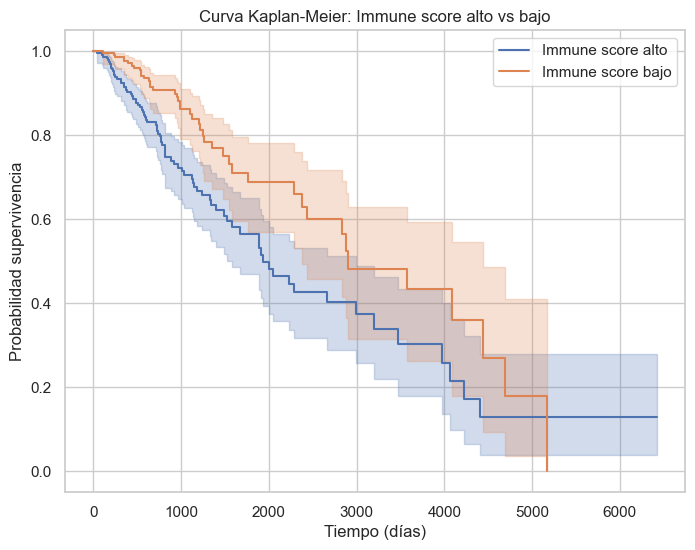

P-valor test log-rank (immune score): 0.0013


In [189]:
import seaborn as sns
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# Definir grupos high y low según mediana es común
median_immune = scores_sub['immune_score'].median()
high_immune = scores_sub['immune_score'] >= median_immune

# Supervivencia Kaplan-Meier para high vs low immune
kmf = KaplanMeierFitter()
T = clin_sub['overall_survival']  # Tiempo supervivencia (ej: días)
E = clin_sub['status']  # Evento (1 muerto, 0 censurado)

plt.figure(figsize=(8,6))
kmf.fit(T[high_immune], event_observed=E[high_immune], label='Immune score alto')
ax = kmf.plot_survival_function()
kmf.fit(T[~high_immune], event_observed=E[~high_immune], label='Immune score bajo')
kmf.plot_survival_function(ax=ax)
plt.title('Curva Kaplan-Meier: Immune score alto vs bajo')
plt.xlabel('Tiempo (días)')
plt.ylabel('Probabilidad supervivencia')
plt.show()

# Test log-rank para comparar grupos
result_logrank = logrank_test(T[high_immune], T[~high_immune], event_observed_A=E[high_immune], event_observed_B=E[~high_immune])
print(f"P-valor test log-rank (immune score): {result_logrank.p_value:.4f}")


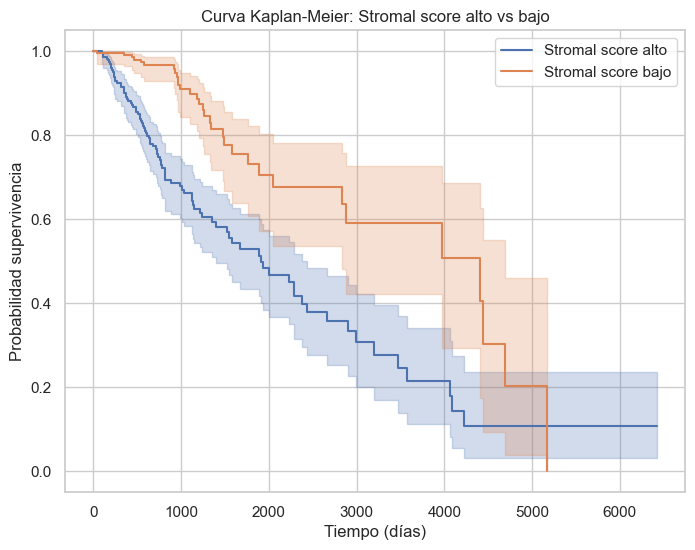

P-valor test log-rank (stromal score): 0.0000


In [190]:
# Definir grupos high y low según mediana es común
median_stromal = scores_sub['stromal_score'].median()
high_stromal = scores_sub['stromal_score'] >= median_stromal

plt.figure(figsize=(8,6))
kmf.fit(T[high_stromal], event_observed=E[high_stromal], label='Stromal score alto')
ax = kmf.plot_survival_function()
kmf.fit(T[~high_stromal], event_observed=E[~high_stromal], label='Stromal score bajo')
kmf.plot_survival_function(ax=ax)
plt.title('Curva Kaplan-Meier: Stromal score alto vs bajo')
plt.xlabel('Tiempo (días)')
plt.ylabel('Probabilidad supervivencia')
plt.show()

# Test log-rank para comparar grupos
result_logrank = logrank_test(T[high_stromal], T[~high_stromal], event_observed_A=E[high_stromal], event_observed_B=E[~high_stromal])
print(f"P-valor test log-rank (stromal score): {result_logrank.p_value:.4f}")

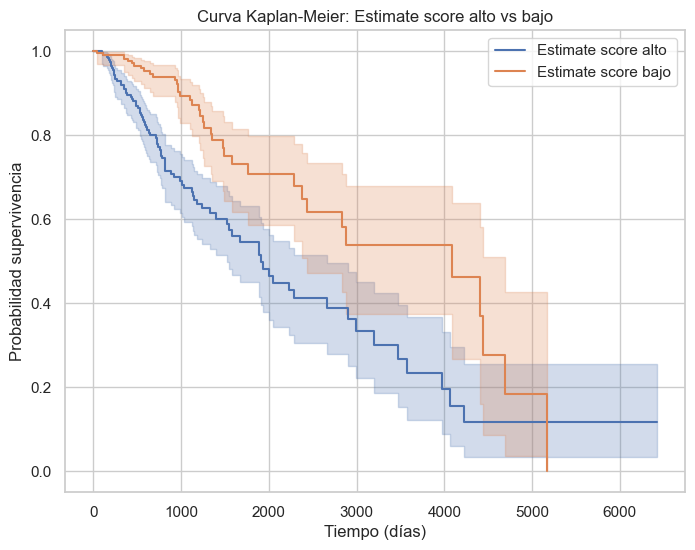

P-valor test log-rank (estimate score): 0.0000


In [191]:
# Definir grupos high y low según mediana es común
median_estimate = scores_sub['estimate_score'].median()
high_estimate = scores_sub['estimate_score'] >= median_estimate

plt.figure(figsize=(8,6))
kmf.fit(T[high_estimate], event_observed=E[high_estimate], label='Estimate score alto')
ax = kmf.plot_survival_function()
kmf.fit(T[~high_estimate], event_observed=E[~high_estimate], label='Estimate score bajo')
kmf.plot_survival_function(ax=ax)
plt.title('Curva Kaplan-Meier: Estimate score alto vs bajo')
plt.xlabel('Tiempo (días)')
plt.ylabel('Probabilidad supervivencia')
plt.show()

# Test log-rank para comparar grupos
result_logrank = logrank_test(T[high_estimate], T[~high_estimate], event_observed_A=E[high_estimate], event_observed_B=E[~high_estimate])
print(f"P-valor test log-rank (estimate score): {result_logrank.p_value:.4f}")

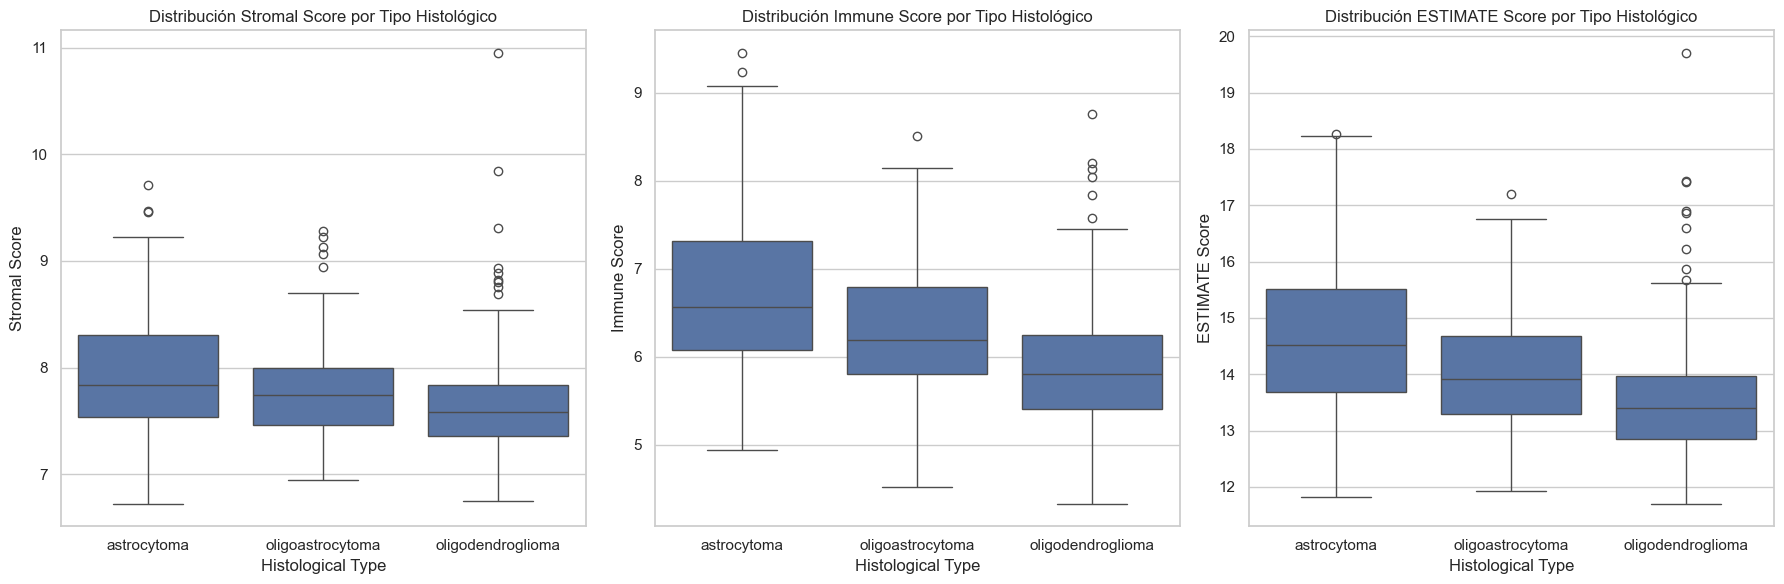

In [192]:
import seaborn as sns
import matplotlib.pyplot as plt

data = scores_sub.join(clin['histological_type'])
data = data.dropna(subset=['stromal_score', 'immune_score', 'estimate_score', 'histological_type'])

# Configurar estilo
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Boxplot para Stromal Score
sns.boxplot(x='histological_type', y='stromal_score', data=data, ax=axes[0])
axes[0].set_title('Distribución Stromal Score por Tipo Histológico')
axes[0].set_xlabel('Histological Type')
axes[0].set_ylabel('Stromal Score')

# Boxplot para Immune Score
sns.boxplot(x='histological_type', y='immune_score', data=data, ax=axes[1])
axes[1].set_title('Distribución Immune Score por Tipo Histológico')
axes[1].set_xlabel('Histological Type')
axes[1].set_ylabel('Immune Score')

# Boxplot para ESTIMATE Score
sns.boxplot(x='histological_type', y='estimate_score', data=data,
ax=axes[2])
axes[2].set_title('Distribución ESTIMATE Score por Tipo Histológico')
axes[2].set_xlabel('Histological Type')
axes[2].set_ylabel('ESTIMATE Score')

plt.tight_layout()
plt.show()

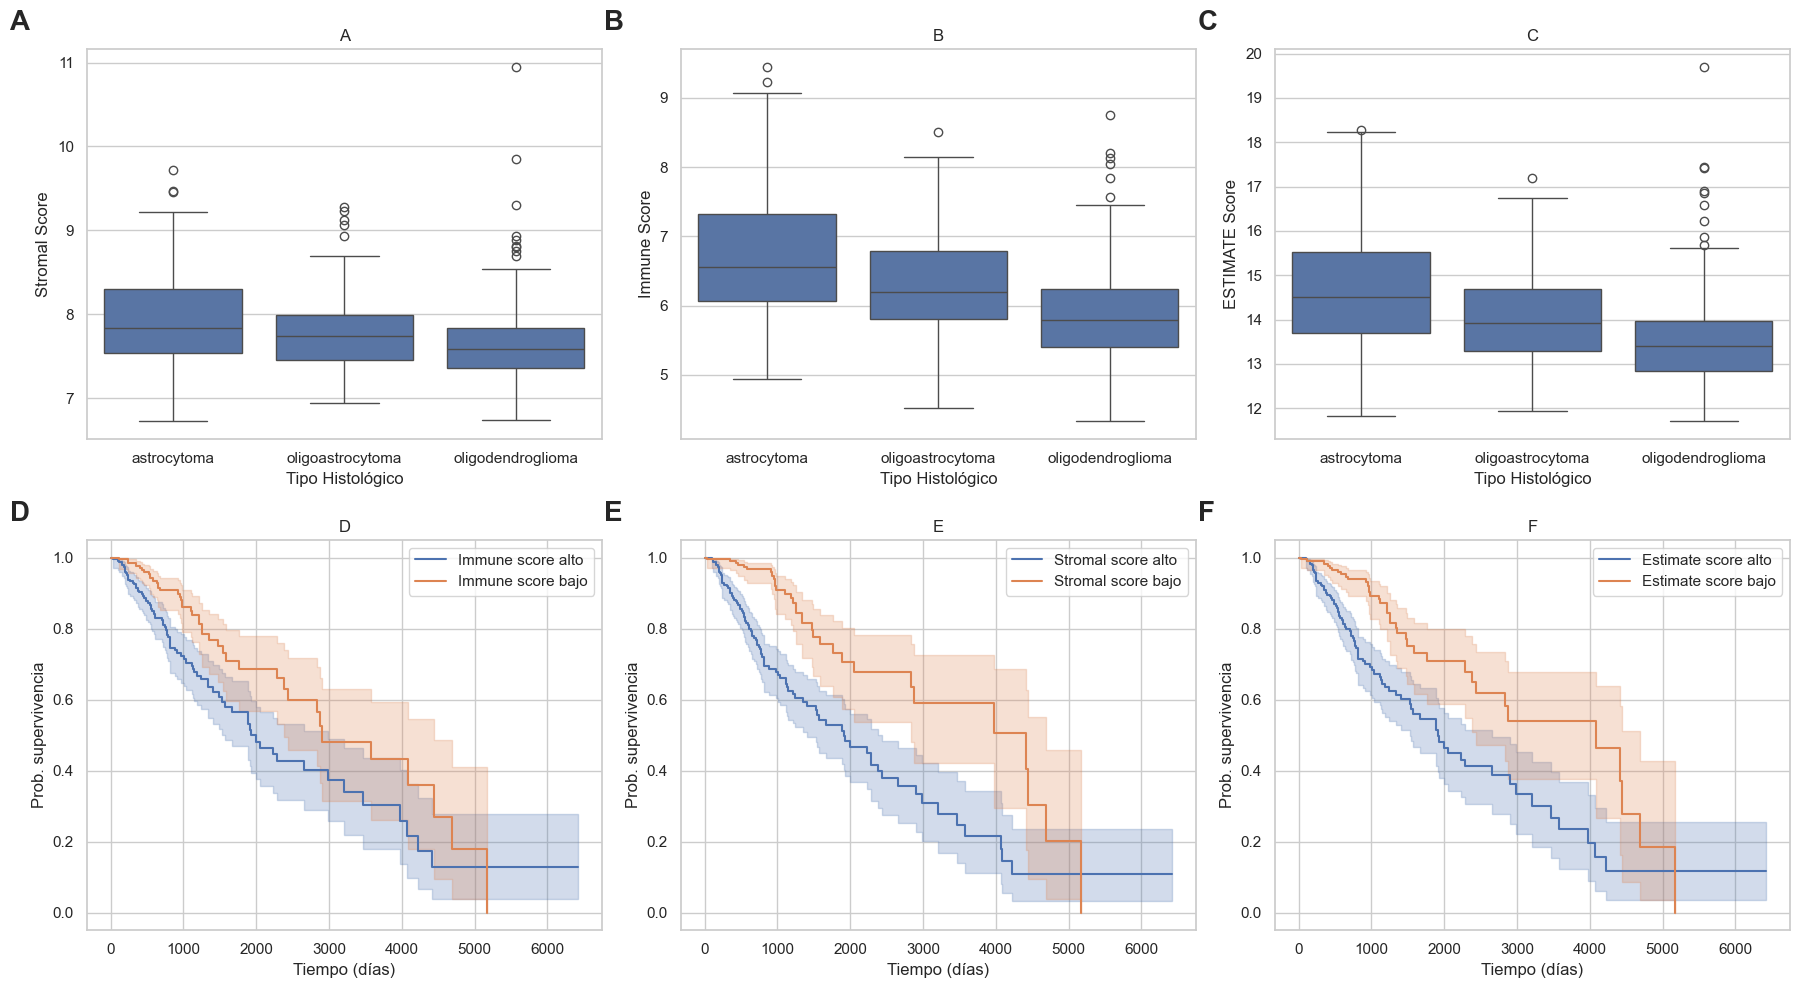

In [193]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Panel A
sns.boxplot(x='histological_type', y='stromal_score', data=data, ax=axes[0, 0])
axes[0, 0].set_title('A')
axes[0, 0].set_xlabel('Tipo Histológico')
axes[0, 0].set_ylabel('Stromal Score')
axes[0, 0].text(-0.15, 1.10, 'A', transform=axes[0, 0].transAxes, fontsize=20, fontweight='bold', va='top', ha='left')

# Panel B
sns.boxplot(x='histological_type', y='immune_score', data=data, ax=axes[0, 1])
axes[0, 1].set_title('B')
axes[0, 1].set_xlabel('Tipo Histológico')
axes[0, 1].set_ylabel('Immune Score')
axes[0, 1].text(-0.15, 1.10, 'B', transform=axes[0, 1].transAxes, fontsize=20, fontweight='bold', va='top', ha='left')

# Panel C
sns.boxplot(x='histological_type', y='estimate_score', data=data, ax=axes[0, 2])
axes[0, 2].set_title('C')
axes[0, 2].set_xlabel('Tipo Histológico')
axes[0, 2].set_ylabel('ESTIMATE Score')
axes[0, 2].text(-0.15, 1.10, 'C', transform=axes[0, 2].transAxes, fontsize=20, fontweight='bold', va='top', ha='left')

# Panel D
kmf = KaplanMeierFitter()
kmf.fit(T[high_immune], event_observed=E[high_immune], label='Immune score alto')
kmf.plot_survival_function(ax=axes[1, 0])
kmf.fit(T[~high_immune], event_observed=E[~high_immune], label='Immune score bajo')
kmf.plot_survival_function(ax=axes[1, 0])
axes[1, 0].set_title('D')
axes[1, 0].set_xlabel('Tiempo (días)')
axes[1, 0].set_ylabel('Prob. supervivencia')
axes[1, 0].text(-0.15, 1.10, 'D', transform=axes[1, 0].transAxes, fontsize=20, fontweight='bold', va='top', ha='left')

# Panel E
kmf.fit(T[high_stromal], event_observed=E[high_stromal], label='Stromal score alto')
kmf.plot_survival_function(ax=axes[1, 1])
kmf.fit(T[~high_stromal], event_observed=E[~high_stromal], label='Stromal score bajo')
kmf.plot_survival_function(ax=axes[1, 1])
axes[1, 1].set_title('E')
axes[1, 1].set_xlabel('Tiempo (días)')
axes[1, 1].set_ylabel('Prob. supervivencia')
axes[1, 1].text(-0.15, 1.10, 'E', transform=axes[1, 1].transAxes, fontsize=20, fontweight='bold', va='top', ha='left')

# Panel F
kmf.fit(T[high_estimate], event_observed=E[high_estimate], label='Estimate score alto')
kmf.plot_survival_function(ax=axes[1, 2])
kmf.fit(T[~high_estimate], event_observed=E[~high_estimate], label='Estimate score bajo')
kmf.plot_survival_function(ax=axes[1, 2])
axes[1, 2].set_title('F')
axes[1, 2].set_xlabel('Tiempo (días)')
axes[1, 2].set_ylabel('Prob. supervivencia')
axes[1, 2].text(-0.15, 1.10, 'F', transform=axes[1, 2].transAxes, fontsize=20, fontweight='bold', va='top', ha='left')

plt.tight_layout()
plt.savefig('figura_paper_LGG_panel_letras.png', dpi=300)
plt.show()

## Identificación de genes diferencialmente expresados (DEGs)

La identificación de genes diferencialemente expresados entre grupos alto y bajo puntajes immune y stromal mediante los siguientes criterios:
- $|\log_2(\text{FC})| > 1$ (Fold Change)
- FDR (False Discovery Rate) < 0.05

Son intersectadas las listas de DEGs comunes a ambos puntajes.

In [194]:
scores_sub.head()

,immune_score,stromal_score,estimate_score
TCGA.CS.6665,7.928820,8.307347,16.236166
TCGA.CS.6670,5.218867,7.616709,12.835575
TCGA.DB.A4XC,6.620606,7.846267,14.466873
TCGA.DH.5141,5.894965,7.715391,13.610356
TCGA.DH.A66B,7.272471,7.539039,14.811510


In [195]:
from scipy.stats import ttest_ind

common_samples = expr.columns.intersection(scores_sub.index)

# Subconjunto las muestras comunes para ambos datasets
expr_common = expr.loc[:, common_samples]
scores_sub_common = scores_sub.loc[common_samples]

scores_names = ['immune_score', 'stromal_score', 'estimate_score']

# Diccionarios para guardar resultados por score
deg_results = {}

for score_name in scores_names:
    print(f"Procesando DEGs para {score_name} ...")
    median_score = scores_sub_common[score_name].median()
    
    # Definir grupos alto y bajo para ese score
    high_group = scores_sub_common[score_name] >= median_score
    low_group = ~high_group
    
    # Seleccionar expresión para grupos alto/bajo (los genes están en filas)
    expr_high = expr_common.loc[:, high_group.index[high_group]].copy()
    expr_low = expr_common.loc[:, low_group.index[low_group]].copy()
    
    # Vectores para p-values y logFC
    pvals = []
    logFC = []
    genes = expr_common.index
    
    # Calcular t-test y fc para cada gen
    for gene in genes:
        group1 = expr_high.loc[gene].values
        group2 = expr_low.loc[gene].values
        
        # t-test con varianza desigual (Welch)
        stat, p = ttest_ind(group1, group2, equal_var=False)
        pvals.append(p)
        
        # Fold change promedio (diferencia de medias)
        fc = group1.mean() - group2.mean()  # log2 fold change si expresión es log2-transformada
        logFC.append(fc)
        
    # Crear DataFrame con resultados
    deg_df = pd.DataFrame({
        'gene': genes,
        'logFC': logFC,
        'p_value': pvals
    })
    
    # Corrección Bonferroni (ajuste simple)
    deg_df['adj_p_value'] = deg_df['p_value'] * len(deg_df)
    deg_df['adj_p_value'] = deg_df['adj_p_value'].clip(upper=1)  # corregir valores >1
    
    # Filtrar DEGs significativos: |logFC| > 1 y adj_p_value < 0.05
    deg_sig = deg_df[(deg_df['adj_p_value'] < 0.05) & (deg_df['logFC'].abs() > 1)].copy()
    deg_sig = deg_sig.sort_values('adj_p_value')
    
    # Guardar resultados
    deg_results[score_name] = {
        'all': deg_df,
        'significant': deg_sig
    }
    
    print(f"Score {score_name}: genes diferencialmente expresados significativos = {len(deg_sig)}")
    print(deg_sig.head(), '\n')

Procesando DEGs para immune_score ...
Score immune_score: genes diferencialmente expresados significativos = 1237
          gene     logFC       p_value   adj_p_value
7828   HLA-DRA  2.540546  3.579583e-91  7.189951e-87
3336      CD74  2.255857  9.008415e-91  1.809430e-86
7819   HLA-DOA  2.550684  6.808441e-87  1.367543e-82
7821  HLA-DPA1  2.396949  1.197575e-84  2.405449e-80
7817   HLA-DMA  1.883692  1.951171e-83  3.919121e-79 

Procesando DEGs para stromal_score ...
Score stromal_score: genes diferencialmente expresados significativos = 855
          gene     logFC       p_value   adj_p_value
8544     ITGA5  1.440245  5.886141e-59  1.182290e-54
5849   FAM129A  1.695183  8.655097e-53  1.738463e-48
4006    COL1A2  1.810255  1.901203e-51  3.818757e-47
3602       CFH  1.461562  5.773508e-50  1.159667e-45
11350     MYOF  1.405933  1.320486e-49  2.652328e-45 

Procesando DEGs para estimate_score ...
Score estimate_score: genes diferencialmente expresados significativos = 1248
          gen

## Análisis funcional y enriquecimiento

Análisis de enriquecimiento funcional con:
- Gene Ontology: procesos biológicos, funciones moleculares y componentes celulares.
- KEGG: rutas metaólicas y de señalización.

In [196]:
import gseapy as gp

# Preparar lista de genes up-regulados y down-regulados
genes_up = deg_sig[deg_sig['logFC'] > 1]['gene'].tolist()
genes_down = deg_sig[deg_sig['logFC'] < -1]['gene'].tolist()

# Enriquecimiento KEGG por ejemplo para genes up
enr_up = gp.enrichr(
    gene_list=genes_up,
    gene_sets=['KEGG_2021_Human'],
    organism='Human',
    outdir=None,  # no genera archivos
    cutoff=0.05
)
print("Enriquecimiento KEGG - genes UP regulados (top 5):")
print(enr_up.results.head())


Enriquecimiento KEGG - genes UP regulados (top 5):
          Gene_set                             Term Overlap       P-value  \
0  KEGG_2021_Human  Staphylococcus aureus infection   42/95  5.505934e-29   
1  KEGG_2021_Human                        Phagosome  49/152  4.342931e-26   
2  KEGG_2021_Human       Osteoclast differentiation  43/127  5.113150e-24   
3  KEGG_2021_Human       Hematopoietic cell lineage   37/99  1.410812e-22   
4  KEGG_2021_Human                    Leishmaniasis   33/77  1.597991e-22   

   Adjusted P-value  Old P-value  Old Adjusted P-value  Odds Ratio  \
0      1.486602e-26            0                     0   15.076535   
1      5.862957e-24            0                     0    9.090890   
2      4.601835e-22            0                     0    9.732892   
3      8.629153e-21            0                     0   11.291517   
4      8.629153e-21            0                     0   14.147557   

   Combined Score                                              Ge

In [197]:
print(genes_up)

['HLA-DRA', 'CD74', 'HLA-DPA1', 'HLA-DOA', 'HLA-DPB1', 'HLA-DRB1', 'HLA-DMA', 'PLBD1', 'CASP4', 'SP100', 'CIITA', 'ADPRH', 'KYNU', 'SERPINA1', 'SQRDL', 'MSR1', 'HLA-DMB', 'HLA-E', 'CCR5', 'HLA-DQA1', 'S100A4', 'RAC2', 'FAM129A', 'S100A11', 'GPR65', 'CLIC1', 'PTGER4', 'IL2RG', 'GBP5', 'TRIM38', 'FGL2', 'CTSC', 'APOBEC3G', 'FCGR2A', 'CASP8', 'IFI30', 'DENND2D', 'ARHGAP15', 'LTBR', 'TNFAIP8', 'CECR1', 'CTSS', 'PLSCR1', 'MSN', 'FCGR2C', 'ELF4', 'CASP1', 'ITGAL', 'CD7', 'CCL5', 'MYOF', 'ARHGAP25', 'SP140L', 'HLA-DRB5', 'CD3E', 'CD2', 'PDCD1LG2', 'FBP1', 'SLC15A3', 'CHI3L2', 'PTPRC', 'CTSZ', 'LYN', 'MX2', 'LAIR1', 'RAB32', 'CARD16', 'FCGR3A', 'SERPINB1', 'ARHGDIB', 'PTPN7', 'MYL12A', 'TLR8', 'CSF2RB', 'TYMP', 'DAPP1', 'MYO1F', 'CYTIP', 'CD69', 'B2M', 'C16orf54', 'TGFBR2', 'APOBEC3C', 'ANXA2P2', 'HLA-B', 'ITGB2', 'RBM47', 'EPSTI1', 'GAPT', 'TRAF3IP3', 'LRRC25', 'LY96', 'GBP1', 'ARPC1B', 'OLFML3', 'SLAMF6', 'LCP2', 'C1R', 'RHOH', 'ITGA5', 'EMR1', 'TNFRSF1B', 'PLCG2', 'SPINT1', 'SERPING1', 'TYR

In [198]:
# Enriquecimiento GO para genes up regulados (BP, CC, MF)
enr_go_bp_up = gp.enrichr(
    gene_list=genes_up,
    gene_sets=['GO_Biological_Process_2025'],
    organism='Human',
    outdir=None,
    cutoff=0.05
)
print("Enriquecimiento GO BP - genes UP regulados (top 5):")
print(enr_go_bp_up.results.head())

enr_go_cc_up = gp.enrichr(
    gene_list=genes_up,
    gene_sets=['GO_Cellular_Component_2025'],
    organism='Human',
    outdir=None,
    cutoff=0.05
)
print("Enriquecimiento GO CC - genes UP regulados (top 5):")
print(enr_go_cc_up.results.head())

enr_go_mf_up = gp.enrichr(
    gene_list=genes_up,
    gene_sets=['GO_Molecular_Function_2025'],
    organism='Human',
    outdir=None,
    cutoff=0.05
)
print("Enriquecimiento GO MF - genes UP regulados (top 5):")
print(enr_go_mf_up.results.head())

Enriquecimiento GO BP - genes UP regulados (top 5):
                     Gene_set  \
0  GO_Biological_Process_2025   
1  GO_Biological_Process_2025   
2  GO_Biological_Process_2025   
3  GO_Biological_Process_2025   
4  GO_Biological_Process_2025   

                                                Term Overlap       P-value  \
0                 Inflammatory Response (GO:0006954)  76/261  2.014922e-36   
1  Positive Regulation of Cytokine Production (GO...  82/325  3.215103e-34   
2   Cytokine-Mediated Signaling Pathway (GO:0019221)  64/255  9.053124e-27   
3    Regulation of T Cell Proliferation (GO:0042129)   36/83  1.133883e-24   
4  Regulation of Tumor Necrosis Factor Production...  44/131  2.204612e-24   

   Adjusted P-value  Old P-value  Old Adjusted P-value  Odds Ratio  \
0      6.344990e-33            0                     0    8.036059   
1      5.062180e-31            0                     0    6.621986   
2      9.502763e-24            0                     0    6.471635   


In [199]:
def plot_enrichment(enr_result, title, top_n=10, figsize=(8, 6), color='skyblue'):
    """
    Grafica los top_n términos de enriquecimiento por -log10(p-value).
    """
    if enr_result.results.empty:
        print(f"⚠️  No hay resultados significativos para: {title}")
        return
    
    # Seleccionar los top_n términos más significativos
    df_plot = enr_result.results.sort_values('P-value').head(top_n).copy()
    df_plot['-log10(P-value)'] = -np.log10(df_plot['P-value'] + 1e-300)  # evitar log(0)
    
    # Invertir el orden para que el más significativo esté arriba
    df_plot = df_plot.iloc[::-1]
    
    plt.figure(figsize=figsize)
    sns.barplot(
        data=df_plot,
        x='-log10(P-value)',
        y='Term',
        color=color,
        edgecolor='black',
        linewidth=0.5
    )
    plt.title(title, fontsize=14, weight='bold')
    plt.xlabel('-log₁₀(p-value)', fontsize=12)
    plt.ylabel('Término / Vía', fontsize=12)
    plt.tight_layout()
    plt.show()

C:\Users\Antonio\AppData\Local\Temp\ipykernel_12252\1766013477.py:28: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Antonio\AppData\Local\Temp\ipykernel_12252\1766013477.py:28: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
d:\Coding\investigacionIA\entorno\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Coding\investigacionIA\entorno\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


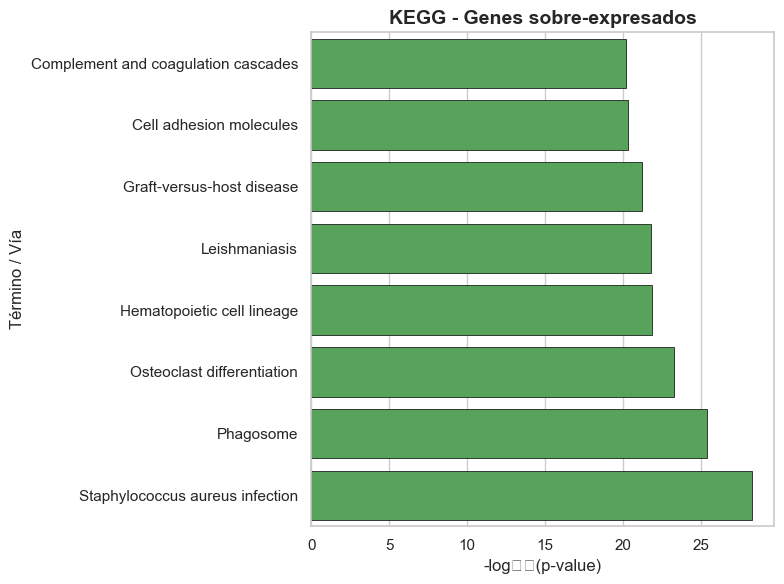

C:\Users\Antonio\AppData\Local\Temp\ipykernel_12252\1766013477.py:28: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Antonio\AppData\Local\Temp\ipykernel_12252\1766013477.py:28: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
d:\Coding\investigacionIA\entorno\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Coding\investigacionIA\entorno\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


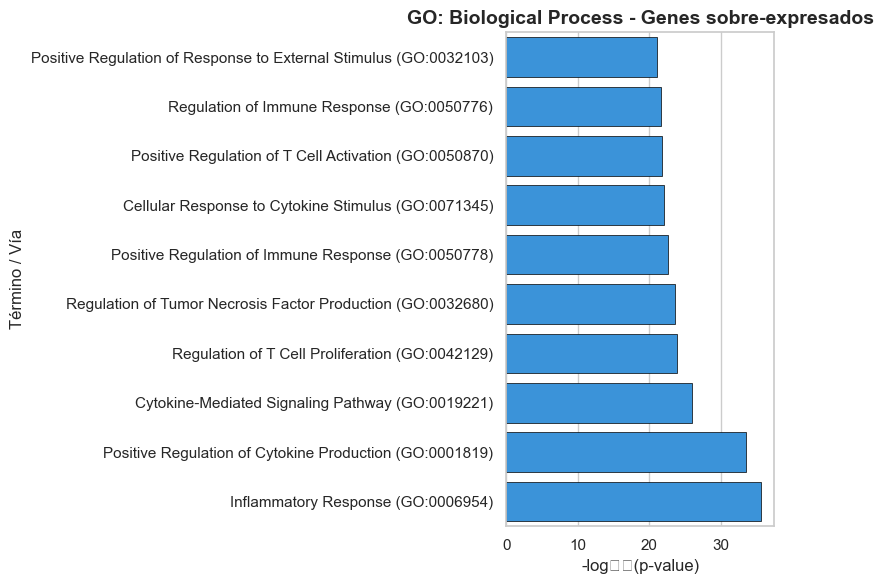

C:\Users\Antonio\AppData\Local\Temp\ipykernel_12252\1766013477.py:28: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Antonio\AppData\Local\Temp\ipykernel_12252\1766013477.py:28: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
d:\Coding\investigacionIA\entorno\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Coding\investigacionIA\entorno\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


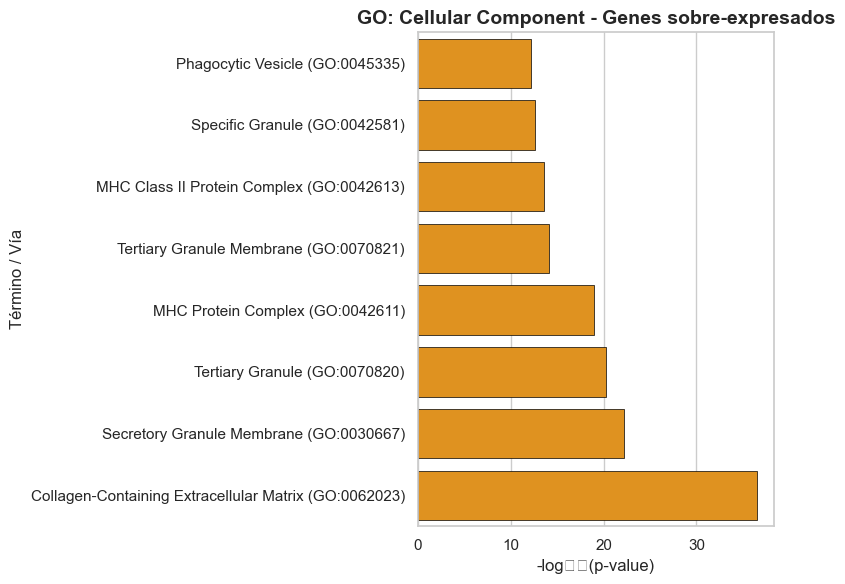

C:\Users\Antonio\AppData\Local\Temp\ipykernel_12252\1766013477.py:28: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Antonio\AppData\Local\Temp\ipykernel_12252\1766013477.py:28: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
d:\Coding\investigacionIA\entorno\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Coding\investigacionIA\entorno\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


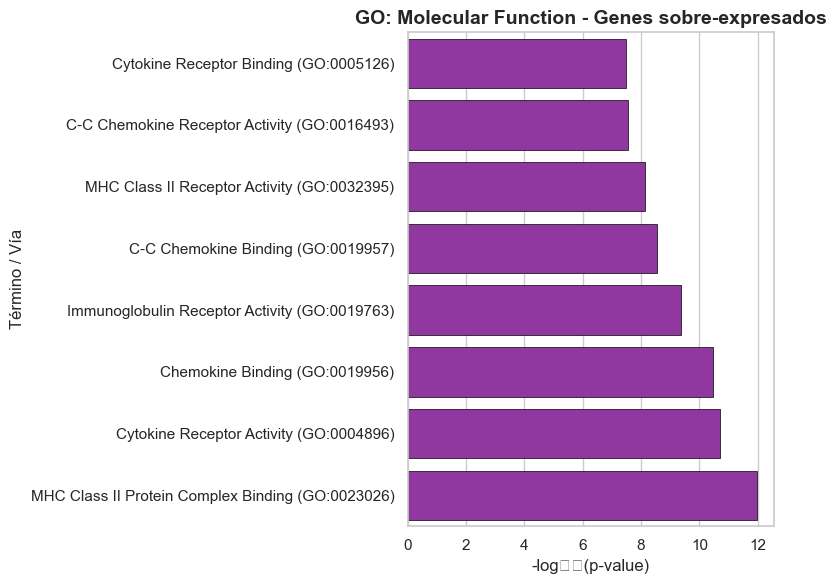

In [200]:
# KEGG
plot_enrichment(
    enr_up, 
    title="KEGG - Genes sobre-expresados", 
    top_n=8, 
    color='#4CAF50'
)

# GO Biological Process
plot_enrichment(
    enr_go_bp_up, 
    title="GO: Biological Process - Genes sobre-expresados", 
    top_n=10, 
    color='#2196F3'
)

# GO Cellular Component
plot_enrichment(
    enr_go_cc_up, 
    title="GO: Cellular Component - Genes sobre-expresados", 
    top_n=8, 
    color='#FF9800'
)

# GO Molecular Function
plot_enrichment(
    enr_go_mf_up, 
    title="GO: Molecular Function - Genes sobre-expresados", 
    top_n=8, 
    color='#9C27B0'
)

In [201]:
def dotplot_enrichment(enr_result, title, top_n=10, figsize=(8, 6), cmap='viridis'):
    """
    Genera un dot plot (bolas) para resultados de enriquecimiento.
    """
    if enr_result.results.empty:
        print(f"⚠️  No hay resultados significativos para: {title}")
        return

    # Seleccionar los top_n términos más significativos
    df = enr_result.results.sort_values('P-value').head(top_n).copy()
    df = df.iloc[::-1]  # invertir para que el más significativo quede arriba

    # Calcular -log10(p-value)
    df['-log10(P)'] = -np.log10(df['P-value'] + 1e-300)

    # El tamaño de los puntos será proporcional al número de genes en el término
    # Extraer número de genes desde la columna 'Genes' (lista separada por ';')
    df['Gene_count'] = df['Genes'].apply(lambda x: len(x.split(';')))

    # Normalizar el tamaño para la visualización (opcional)
    size_min, size_max = 50, 500
    df['size_scaled'] = np.interp(df['Gene_count'], 
                                  (df['Gene_count'].min(), df['Gene_count'].max()), 
                                  (size_min, size_max))

    # Crear el gráfico
    plt.figure(figsize=figsize)
    scatter = plt.scatter(
        x='-log10(P)',
        y='Term',
        s='size_scaled',
        c='-log10(P)',  # color por significancia
        data=df,
        cmap=cmap,
        edgecolor='k',
        linewidth=0.5,
        alpha=0.8
    )
    
    plt.title(title, fontsize=14, weight='bold')
    plt.xlabel('-log₁₀(p-value)', fontsize=12)
    plt.ylabel('Término / Vía', fontsize=12)
    
    # Añadir barra de color
    plt.colorbar(scatter, label='-log₁₀(p-value)')
    
    plt.tight_layout()
    plt.show()

C:\Users\Antonio\AppData\Local\Temp\ipykernel_12252\542238663.py:47: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Antonio\AppData\Local\Temp\ipykernel_12252\542238663.py:47: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
d:\Coding\investigacionIA\entorno\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Coding\investigacionIA\entorno\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


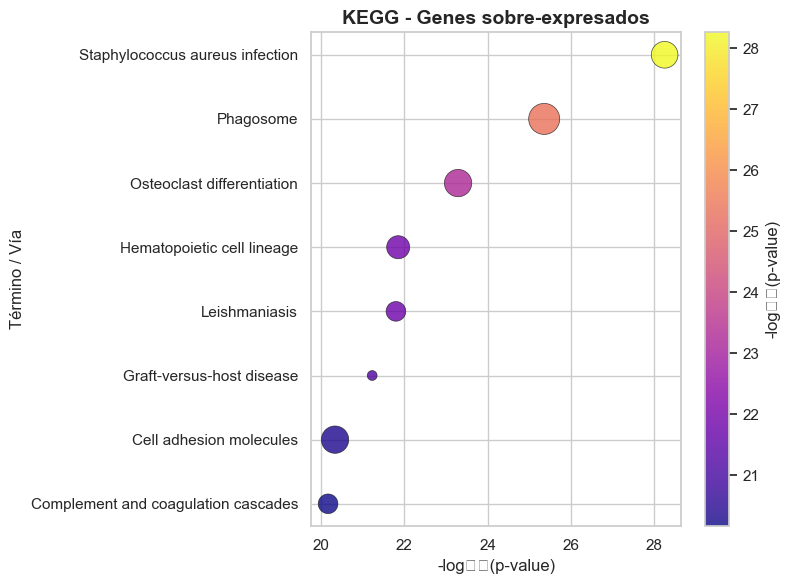

C:\Users\Antonio\AppData\Local\Temp\ipykernel_12252\542238663.py:47: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Antonio\AppData\Local\Temp\ipykernel_12252\542238663.py:47: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
d:\Coding\investigacionIA\entorno\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Coding\investigacionIA\entorno\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


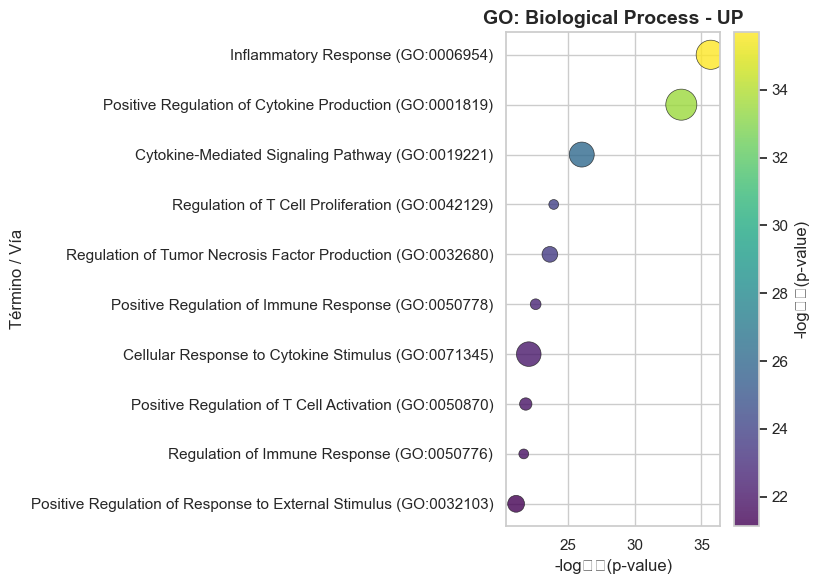

C:\Users\Antonio\AppData\Local\Temp\ipykernel_12252\542238663.py:47: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Antonio\AppData\Local\Temp\ipykernel_12252\542238663.py:47: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
d:\Coding\investigacionIA\entorno\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Coding\investigacionIA\entorno\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


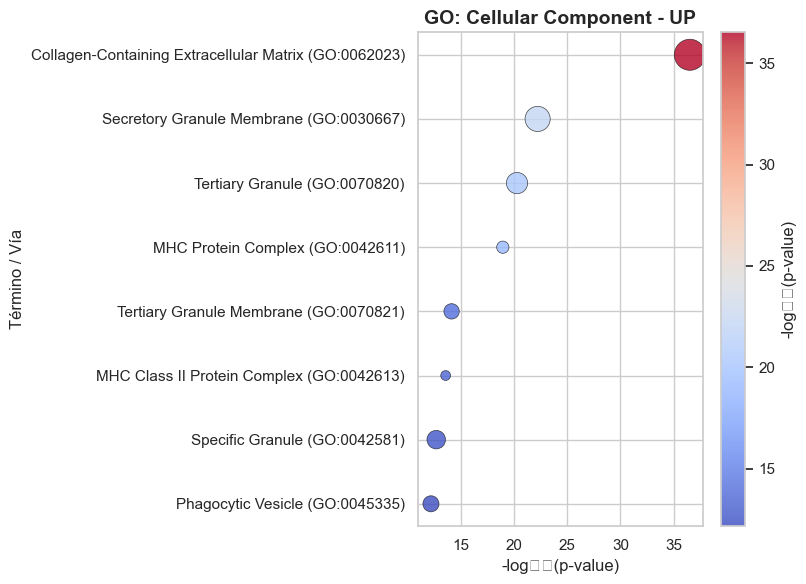

C:\Users\Antonio\AppData\Local\Temp\ipykernel_12252\542238663.py:47: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Antonio\AppData\Local\Temp\ipykernel_12252\542238663.py:47: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
d:\Coding\investigacionIA\entorno\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Coding\investigacionIA\entorno\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


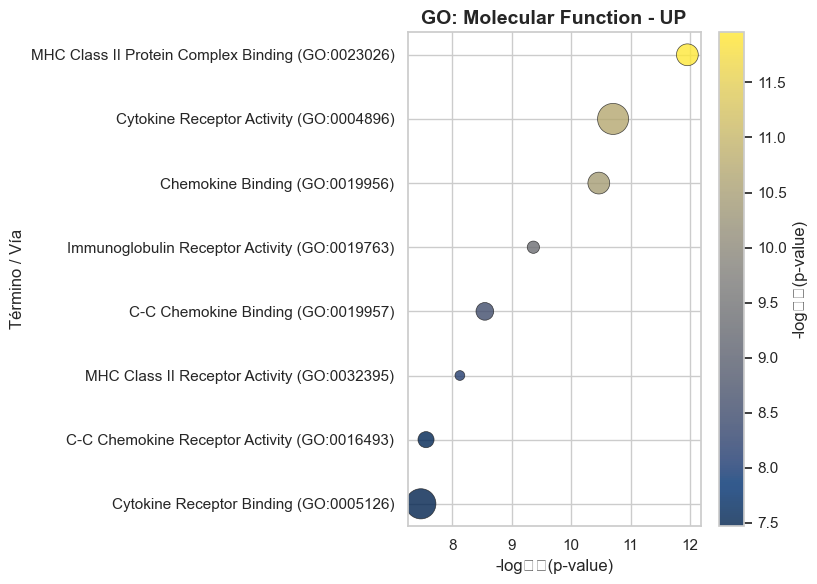

In [202]:
# KEGG
dotplot_enrichment(
    enr_up, 
    title="KEGG - Genes sobre-expresados", 
    top_n=8, 
    cmap='plasma'
)

# GO Biological Process
dotplot_enrichment(
    enr_go_bp_up, 
    title="GO: Biological Process - UP", 
    top_n=10, 
    cmap='viridis'
)

# GO Cellular Component
dotplot_enrichment(
    enr_go_cc_up, 
    title="GO: Cellular Component - UP", 
    top_n=8, 
    cmap='coolwarm'
)

# GO Molecular Function
dotplot_enrichment(
    enr_go_mf_up, 
    title="GO: Molecular Function - UP", 
    top_n=8, 
    cmap='cividis'
)

<Figure size 1600x600 with 0 Axes>

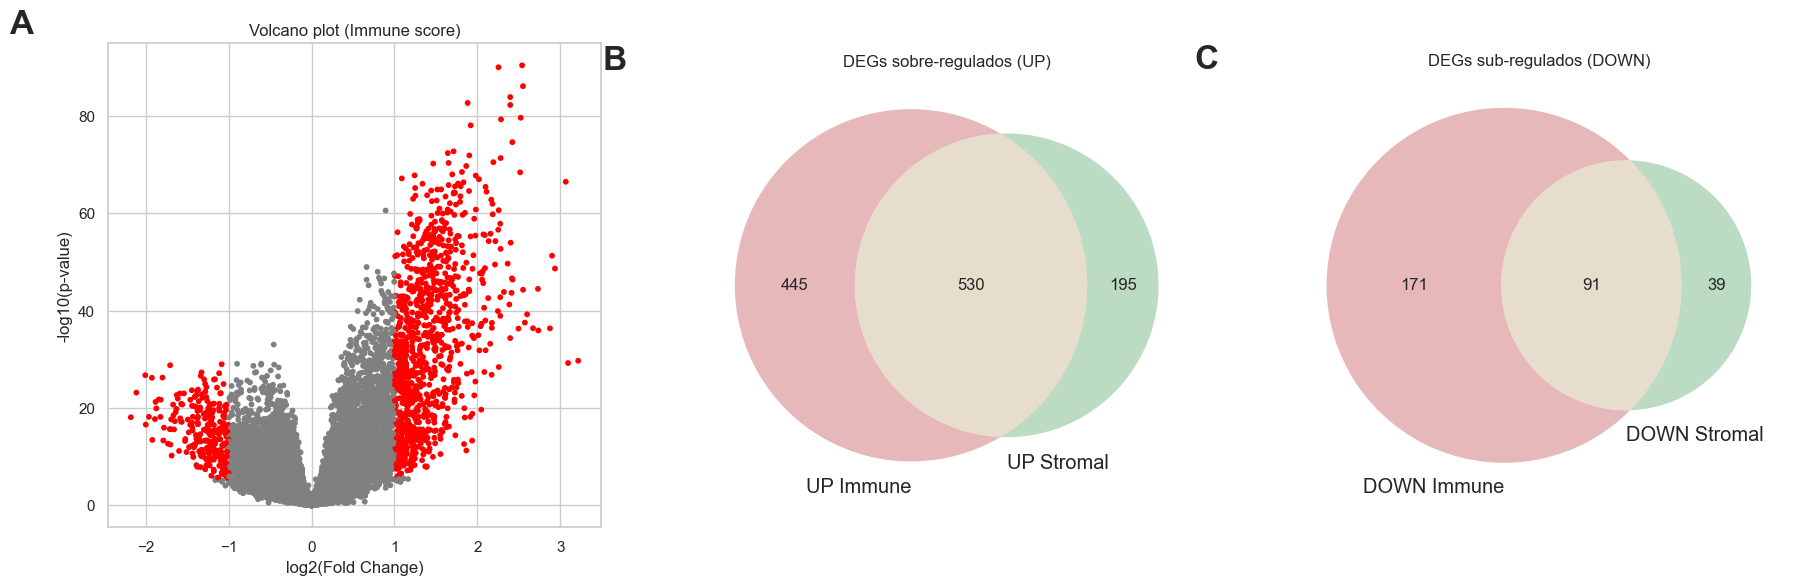

In [203]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib_venn import venn2
import seaborn as sns

# Ejemplo de uso: deg_results["immune_score"]['all'], deg_results["stromal_score"]['all']
# Panel A: Volcano plot (para immune_score)
deg_df = deg_results["immune_score"]['all']
plt.figure(figsize=(16, 6))
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel A
axA = axes[0]
fc = deg_df['logFC'].values
p = deg_df['p_value'].values
axA.scatter(fc, -np.log10(p), c=np.where((deg_df['logFC'].abs() > 1) & (deg_df['adj_p_value'] < 0.05), 'red', 'grey'), s=10)
axA.set_xlabel('log2(Fold Change)')
axA.set_ylabel('-log10(p-value)')
axA.set_title('Volcano plot (Immune score)')
axA.text(-0.2, 1.07, 'A', transform=axA.transAxes, fontsize=24, fontweight='bold', va='top', ha='left')

# Panel B: Diagrama de Venn genes UP regulados
up_immune = set(deg_results["immune_score"]['significant'][deg_results["immune_score"]['significant']['logFC'] > 1]['gene'])
up_stromal = set(deg_results["stromal_score"]['significant'][deg_results["stromal_score"]['significant']['logFC'] > 1]['gene'])
venn2([up_immune, up_stromal], set_labels=('UP Immune', 'UP Stromal'), ax=axes[1])
axes[1].set_title('DEGs sobre-regulados (UP)')
axes[1].text(-0.2, 1.07, 'B', transform=axes[1].transAxes, fontsize=24, fontweight='bold', va='top', ha='left')

# Panel C: Diagrama de Venn genes DOWN regulados
down_immune = set(deg_results["immune_score"]['significant'][deg_results["immune_score"]['significant']['logFC'] < -1]['gene'])
down_stromal = set(deg_results["stromal_score"]['significant'][deg_results["stromal_score"]['significant']['logFC'] < -1]['gene'])
venn2([down_immune, down_stromal], set_labels=('DOWN Immune', 'DOWN Stromal'), ax=axes[2])
axes[2].set_title('DEGs sub-regulados (DOWN)')
axes[2].text(-0.2, 1.07, 'C', transform=axes[2].transAxes, fontsize=24, fontweight='bold', va='top', ha='left')

plt.tight_layout()
plt.savefig('figura2_DEG_LGG.png', dpi=300)
plt.show()


## Red de interacción proteica (PPI) y selección de genes hub 

Se construye una red PPI con datos STRING (interacciones con score mayor a 0.9). Son identificados 25 genes hub con mayor centralidad evaluando según el grado de cada gen en la red. Estos genes están asociados a procesos inmunes claves. 

In [204]:
import requests

def chunk_list(lst, n):
    """Divide una lista en sublistas de tamaño máximo n."""
    for i in range(0, len(lst), n):
        yield lst[i:i + n]

def get_string_edges(genes, species=9606, min_score=900, batch_size=50):
    """
    Consulta a la API STRING para obtener interacciones entre genes.
    
    Parámetros:
        genes (list): Lista de símbolos génicos (ej. ['TP53', 'EGFR']).
        species (int): Código taxonómico (9606 = Homo sapiens).
        min_score (int): Puntaje mínimo de confianza (0–1000). Ej. 900 = 0.9.
        batch_size (int): Máximo número de genes por llamada a la API (máx recomendado: 50–100).
    
    Retorna:
        list: Lista de tuplas únicas y ordenadas alfabéticamente (geneA, geneB).
    """
    if not genes:
        return []
    
    # Normalizar genes a mayúsculas y eliminar duplicados
    genes_clean = list(set(gene.strip().upper() for gene in genes if gene))
    all_edges = set()  # Usar set para evitar duplicados

    print(f"Consultando STRING para {len(genes_clean)} genes (batch size = {batch_size})...")

    for batch in chunk_list(genes_clean, batch_size):
        # ✅ Corrección clave: sin espacios en la URL y formato correcto de identificadores
        genes_str = "%0d".join(batch)  # %0d = salto de línea codificado (requerido por STRING)
        url = f"https://string-db.org/api/tsv/network?identifiers={genes_str}&species={species}&required_score={min_score}"
        
        try:
            response = requests.get(url, timeout=30)
            response.raise_for_status()  # Lanza excepción si hay error HTTP
        except requests.RequestException as e:
            print(f"⚠️  Error al consultar STRING (batch: {batch[0]}...{batch[-1]}): {e}")
            continue

        lines = response.text.strip().split('\n')
        if len(lines) <= 1:
            continue  # Sin datos

        for line in lines[1:]:
            fields = line.split('\t')
            if len(fields) < 4:
                continue
            protein1 = fields[2].upper()
            protein2 = fields[3].upper()
            # Asegurar que ambas proteínas están en tu lista original
            if protein1 in genes_clean and protein2 in genes_clean:
                # Ordenar para evitar duplicados (A-B == B-A)
                edge = tuple(sorted([protein1, protein2]))
                all_edges.add(edge)

    edges_list = sorted(list(all_edges))  # Lista ordenada y limpia
    print(f"✅ Interacciones recuperadas: {len(edges_list)} (entre {len(genes_clean)} genes)")
    return edges_list

In [205]:
edges_up = get_string_edges(genes_up, min_score=900, batch_size=50)
print(f"Aristas obtenidas: {len(edges_up)}")

Consultando STRING para 1036 genes (batch size = 50)...
✅ Interacciones recuperadas: 55 (entre 1036 genes)
Aristas obtenidas: 55


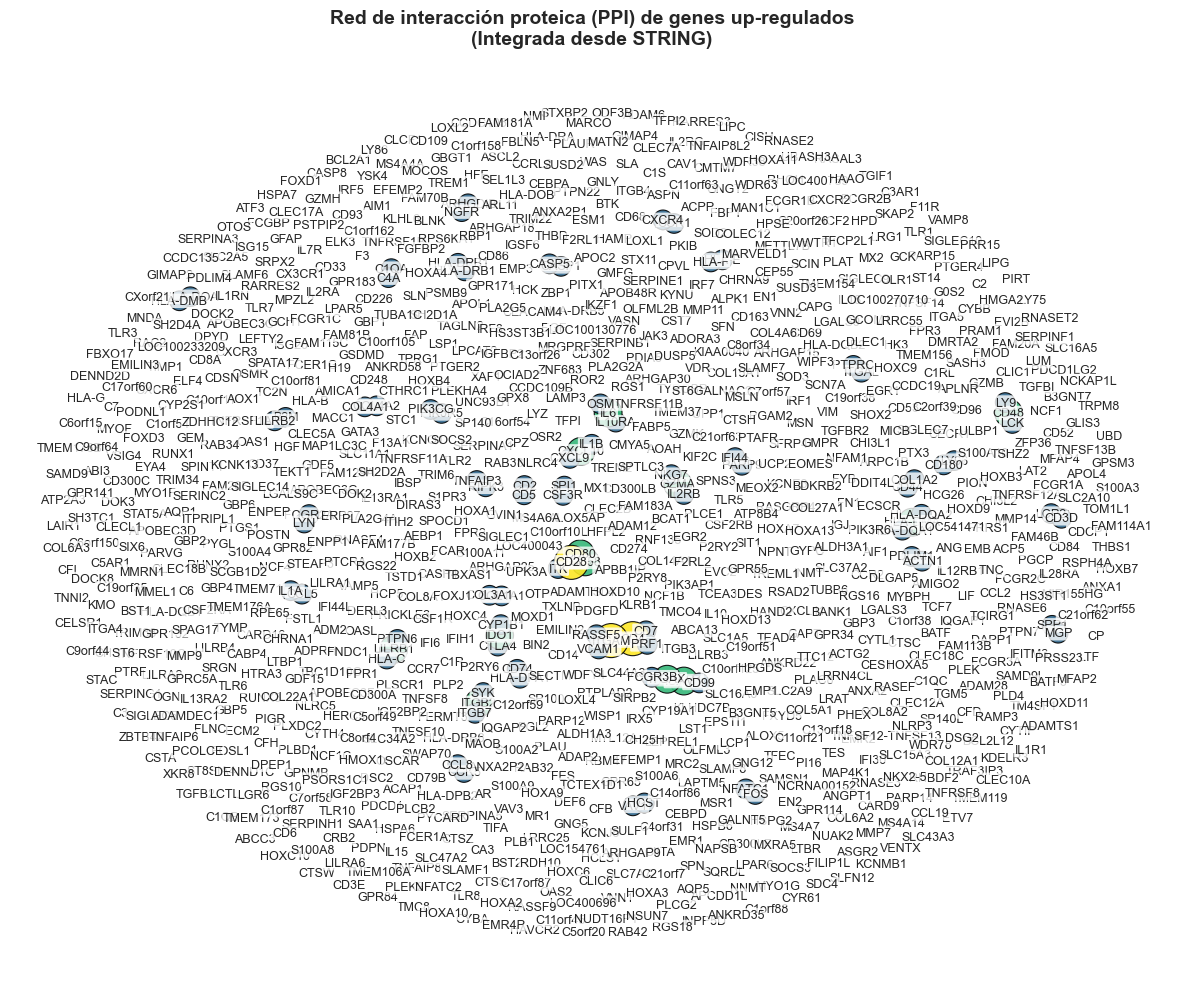

In [206]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Supón que ya tienes:
# - genes_up: lista de genes (nodos)
# - edges_up: lista de tuplas de interacciones (edges)

# 1. Crear grafo
G = nx.Graph()
G.add_nodes_from(genes_up)
G.add_edges_from(edges_up)

# 2. Calcular métricas para mejorar la visualización
degrees = dict(G.degree())
node_sizes = [degrees[node] * 200 for node in G.nodes()]  # tamaño proporcional al grado

# Opcional: si tienes un diccionario de log2FC o p-valor, puedes colorear por eso
# Por ahora, usamos un color por grado (más conectado = más rojo)
degree_values = np.array([degrees[node] for node in G.nodes()])
node_colors = plt.cm.viridis(degree_values / degree_values.max())  # escala de color

# 3. Layout más estable y estético
pos = nx.spring_layout(G, seed=42, k=3/np.sqrt(len(G.nodes())), iterations=50)

# 4. Crear figura
plt.figure(figsize=(12, 10))
ax = plt.gca()

# Dibujar nodos
nx.draw_networkx_nodes(
    G, pos,
    node_size=node_sizes,
    node_color=node_colors,
    edgecolors='black',  # borde fino para definición
    linewidths=0.8,
    alpha=0.9
)

# Dibujar aristas
nx.draw_networkx_edges(
    G, pos,
    width=0.8,
    alpha=0.6,
    edge_color='gray'
)

# Dibujar etiquetas con fondo blanco para mejor legibilidad
for node, (x, y) in pos.items():
    plt.text(
        x, y,
        s=node,
        fontsize=9,
        ha='center',
        va='center',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.1'),
        zorder=10  # asegura que las etiquetas estén encima
    )

# 5. Ajustes finales
plt.title("Red de interacción proteica (PPI) de genes up-regulados\n(Integrada desde STRING)", 
          fontsize=14, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()
plt.savefig("red_ppi_up_regulados.png", dpi=300, bbox_inches='tight')
plt.show()

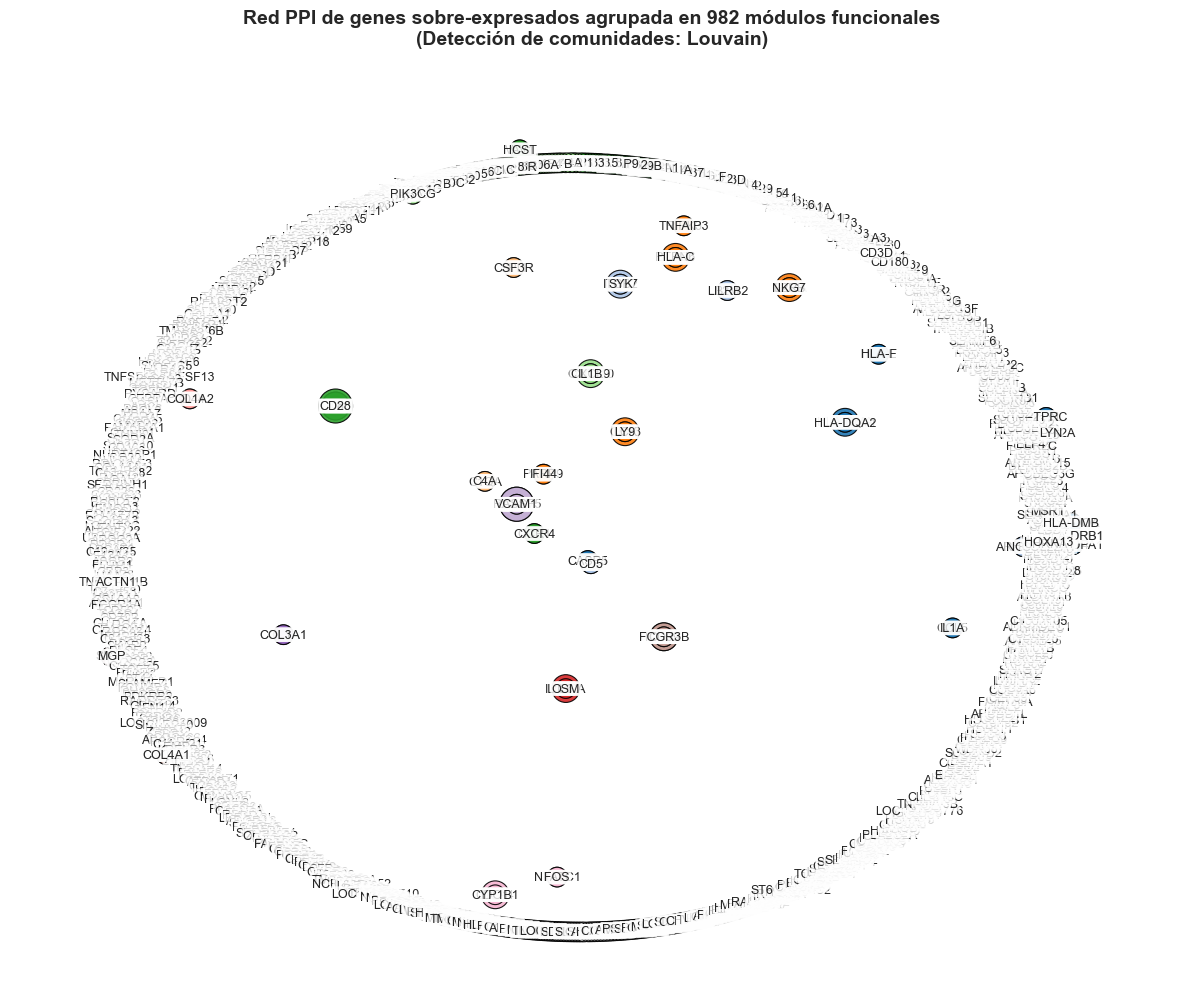

In [207]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Supón que ya tienes:
# - genes_up: lista de genes (nodos)
# - edges_up: lista de tuplas de interacciones (edges)

# 1. Crear grafo
G = nx.Graph()
G.add_nodes_from(genes_up)
G.add_edges_from(edges_up)

# --- NUEVO: Detección de comunidades (reducción funcional de dimensionalidad) ---
try:
    import community as community_louvain
except ImportError:
    raise ImportError("Por favor instala: pip install python-louvain")

# Detectar comunidades con Louvain
partition = community_louvain.best_partition(G, random_state=42)
num_communities = len(set(partition.values()))

# Asignar colores por comunidad
np.random.seed(42)  # reproducibilidad
colors = plt.cm.tab20(np.linspace(0, 1, max(num_communities, 1)))

node_colors = [colors[partition[node]] for node in G.nodes()]

# 2. Calcular tamaños por grado (como en tu código original)
degrees = dict(G.degree())
node_sizes = [max(degrees[node] * 200, 200) for node in G.nodes()]  # mínimo 200 para visibilidad

# 3. Layout más estable (Kamada-Kawai suele separar mejor las comunidades)
pos = nx.kamada_kawai_layout(G)

# 4. Crear figura
plt.figure(figsize=(12, 10))

# Dibujar aristas
nx.draw_networkx_edges(
    G, pos,
    width=0.8,
    alpha=0.5,
    edge_color='lightgray'
)

# Dibujar nodos, coloreados por comunidad
nx.draw_networkx_nodes(
    G, pos,
    node_size=node_sizes,
    node_color=node_colors,
    edgecolors='black',
    linewidths=0.8,
    alpha=0.9
)

# Dibujar etiquetas solo para nodos con grado alto (mejor legibilidad)
grado_umbral = np.percentile(list(degrees.values()), 75)  # top 25%
for node, (x, y) in pos.items():
    if degrees[node] >= grado_umbral:
        plt.text(
            x, y,
            s=node,
            fontsize=9,
            ha='center',
            va='center',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.1'),
            zorder=10
        )

# 5. Ajustes finales
plt.title(f"Red PPI de genes sobre-expresados agrupada en {num_communities} módulos funcionales\n(Detección de comunidades: Louvain)", 
          fontsize=14, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()
plt.savefig("red_ppi_up_regulados_comunidades.png", dpi=300, bbox_inches='tight')
plt.show()

📦 Consultando STRING para 1036 genes (score ≥ 0.5)...
✅ Interacciones recuperadas: 1009

📊 Red inicial: 1037 nodos, 1009 enlaces
🔍 Componentes: 553 (top 5: [87, 50, 48, 47, 46])
🧩 Red tras filtrar componentes (≥3 nodos): 474 nodos, 986 enlaces
🎯 Comunidades detectadas: 16

🖼️  Figura guardada como 'red_ppi_final.png'


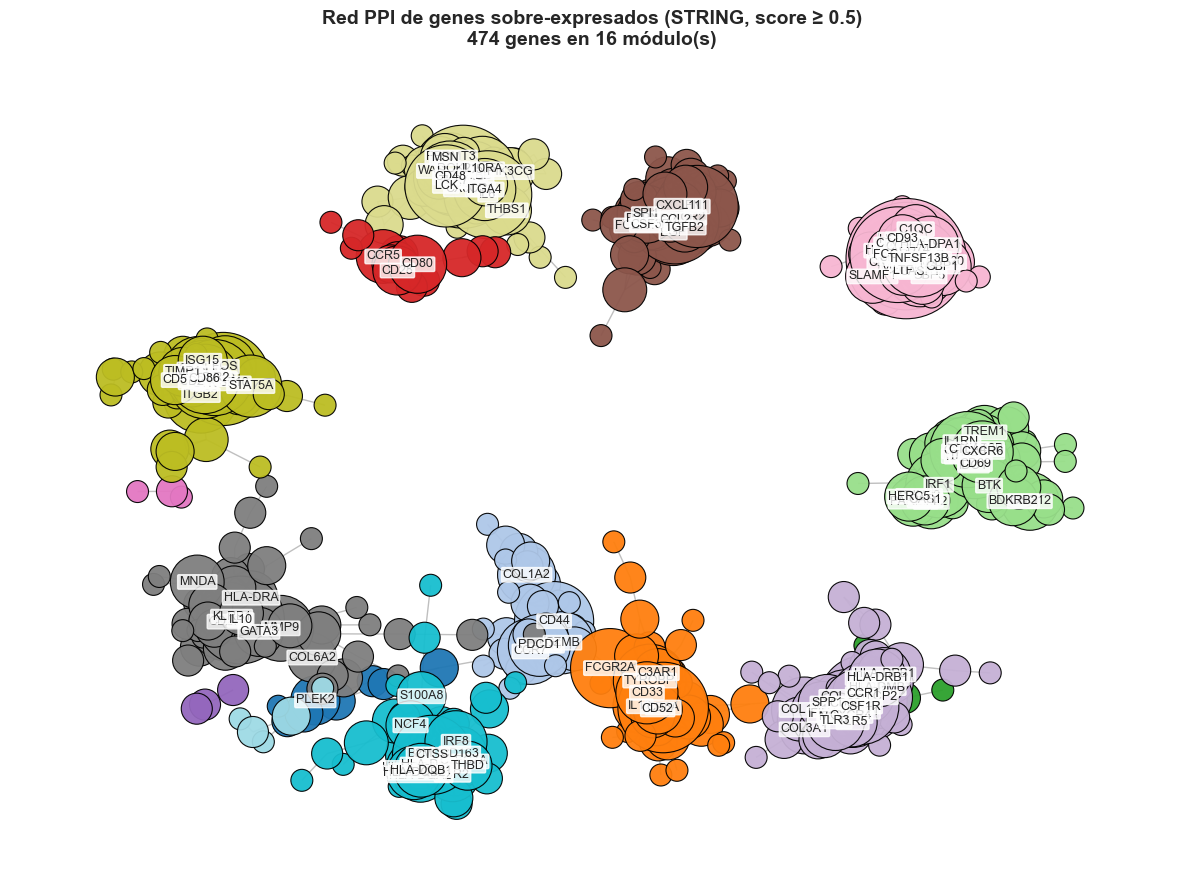

In [223]:
import requests
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------
# 1. FUNCIÓN CORREGIDA PARA STRING (¡SIN ESPACIOS!)
# -------------------------------------------------
def chunk_list(lst, n):
    for i in range(0, len(lst), n):
        yield lst[i:i + n]

def get_string_edges(genes, species=9606, min_score=500, batch_size=100):  # 👈 baja min_score a 500
    if not genes:
        return []
    genes_clean = list(set(gene.strip().upper() for gene in genes if gene))
    all_edges = set()
    print(f"📦 Consultando STRING para {len(genes_clean)} genes (score ≥ {min_score/1000:.1f})...")

    for batch in chunk_list(genes_clean, batch_size):
        genes_str = "%0d".join(batch)
        # ✅ CORRECCIÓN CRÍTICA: elimina los espacios después de 'identifiers='
        url = f"https://string-db.org/api/tsv/network?identifiers={genes_str}&species={species}&required_score={min_score}"
        try:
            response = requests.get(url, timeout=30)
            response.raise_for_status()
        except requests.RequestException as e:
            print(f"⚠️  Error en batch: {e}")
            continue
        for line in response.text.strip().split('\n')[1:]:
            fields = line.split('\t')
            if len(fields) >= 4:
                p1, p2 = fields[2].upper(), fields[3].upper()
                if p1 in genes_clean and p2 in genes_clean:
                    all_edges.add(tuple(sorted([p1, p2])))
    edges_list = sorted(all_edges)
    print(f"✅ Interacciones recuperadas: {len(edges_list)}")
    return edges_list

# -------------------------------------------------
# 2. OBTENER RED — SIN FILTROS AGRESIVOS
# -------------------------------------------------
edges_up = get_string_edges(genes_up, min_score=500, batch_size=100)  # 👈 batch_size más grande

G = nx.Graph()
G.add_nodes_from(genes_up)
G.add_edges_from(edges_up)

print(f"\n📊 Red inicial: {G.number_of_nodes()} nodos, {G.number_of_edges()} enlaces")

# --- Solo diagnóstico (sin eliminar todavía) ---
components = [len(c) for c in nx.connected_components(G)]
print(f"🔍 Componentes: {len(components)} (top 5: {sorted(components, reverse=True)[:5]})")

# -------------------------------------------------
# 3. FILTRADO SUAVE: conservar componentes con ≥ 3 nodos
# -------------------------------------------------
# 👉 En lugar de solo el GCC, conservamos todos los componentes con al menos 3 genes
large_components = [c for c in nx.connected_components(G) if len(c) >= 3]
if not large_components:
    # Si ninguno, al menos toma el GCC aunque sea pequeño
    large_components = [max(nx.connected_components(G), key=len)]

nodes_to_keep = set().union(*large_components)
G = G.subgraph(nodes_to_keep).copy()
print(f"🧩 Red tras filtrar componentes (≥3 nodos): {G.number_of_nodes()} nodos, {G.number_of_edges()} enlaces")

# 👉 NO filtrar por grado mínimo (o usar grado ≥ 1, que no elimina nada)
# Los nodos con grado 1 pueden ser biológicamente relevantes (ej. ligandos)

if G.number_of_nodes() < 3:
    raise ValueError("Red demasiado pequeña. Usa min_score=400 o verifica los genes.")

# -------------------------------------------------
# 4. DETECTAR COMUNIDADES (sin exigir 5–10)
# -------------------------------------------------
try:
    import community as community_louvain
except ImportError:
    raise ImportError("pip install python-louvain")

# Usa resolution=1.0 (por defecto) y acepta cualquier número razonable
partition = community_louvain.best_partition(G, resolution=1.0, random_state=42)
n_comm = len(set(partition.values()))
print(f"🎯 Comunidades detectadas: {n_comm}")

# -------------------------------------------------
# 5. VISUALIZAR — etiquetar más nodos si la red es pequeña
# -------------------------------------------------
np.random.seed(42)
colors = plt.cm.tab20(np.linspace(0, 1, max(n_comm, 1)))
node_colors = [colors[partition[node] % 20] for node in G.nodes()]

degrees = dict(G.degree())
# Si hay pocos nodos, etiquetar todos
if G.number_of_nodes() <= 30:
    node_sizes = [400] * G.number_of_nodes()
    label_all = True
else:
    node_sizes = [max(degrees[node] * 250, 250) for node in G.nodes()]
    label_all = False

pos = nx.spring_layout(G, seed=42, k=3/np.sqrt(G.number_of_nodes()), iterations=100)

plt.figure(figsize=(12, 9))
nx.draw_networkx_edges(G, pos, alpha=0.5, edge_color='gray', width=1.0)
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors,
                       edgecolors='black', linewidths=0.8, alpha=0.95)

# Etiquetas
if label_all:
    nx.draw_networkx_labels(G, pos, font_size=9, font_weight='normal')
else:
    threshold = np.percentile(list(degrees.values()), 70)
    for node, (x, y) in pos.items():
        if degrees[node] >= threshold:
            plt.text(x, y, s=node, fontsize=9, ha='center', va='center',
                     bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.1'))

plt.title(f"Red PPI de genes sobre-expresados (STRING, score ≥ 0.5)\n"
          f"{G.number_of_nodes()} genes en {n_comm} módulo(s)", 
          fontsize=14, fontweight='bold', pad=15)
plt.axis('off')
plt.tight_layout()
plt.savefig("red_ppi_final.png", dpi=300, bbox_inches='tight')
print("\n🖼️  Figura guardada como 'red_ppi_final.png'")
plt.show()

In [224]:
degree_dict = dict(G.degree)
# Ordenar genes por grado descendente
hub_genes_sorted = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)
top_hubs = [gene for gene, deg in hub_genes_sorted[:250]]  # por ejemplo, top 100

print(f"Top {len(top_hubs)} genes hub seleccionados: {top_hubs}")


Top 250 genes hub seleccionados: ['CD4', 'ITGAM', 'PTPRC', 'FCGR3A', 'IL1B', 'CD8A', 'CCL5', 'CCL2', 'IL10', 'IL6', 'FN1', 'LCK', 'CD44', 'FCGR2A', 'ICAM1', 'CD274', 'CTSS', 'CTLA4', 'IL1A', 'CSF1R', 'VCAM1', 'TNFSF13B', 'ITGB2', 'TLR2', 'TYROBP', 'FCGR3B', 'IRF7', 'SPN', 'ITGAL', 'CD48', 'ITGAX', 'CD69', 'CD68', 'CASP1', 'CD74', 'SYK', 'CD86', 'TLR7', 'B2M', 'CCR7', 'IRF1', 'COL1A1', 'IFIH1', 'EGF', 'PSMB9', 'CCL19', 'PRF1', 'MX1', 'MMP9', 'CXCL9', 'CXCL10', 'IL10RA', 'GZMB', 'PDCD1', 'CD33', 'IL7R', 'IDO1', 'CXCR6', 'LCP2', 'CXCR4', 'CCR1', 'FCER1G', 'IL2RB', 'PTPN6', 'HLA-B', 'FOS', 'STAT5A', 'ITGA4', 'IRF8', 'IL15', 'COL1A2', 'CD3E', 'GNG12', 'CD3D', 'AIF1', 'SPP1', 'HLA-DRB1', 'TLR3', 'SPI1', 'HAVCR2', 'CD7', 'HCK', 'GBP5', 'CCRL2', 'GBP1', 'HLA-DPA1', 'CD53', 'HLA-DMA', 'CD80', 'IL18', 'OAS2', 'TREM1', 'BTK', 'HLA-DPB1', 'ISG20', 'FPR1', 'SOCS3', 'SLAMF1', 'HLA-DRA', 'KLRB1', 'MNDA', 'TNFSF10', 'CYBB', 'CX3CR1', 'HLA-DQA1', 'CCR2', 'HLA-DQA2', 'CD163', 'HLA-DQB2', 'HLA-DQB1', 'CC

In [225]:
clin.head()

attrib_name,years_to_birth,Tumor_purity,histological_type,gender,radiation_therapy,race,ethnicity,overall_survival,status
TCGA.CS.6665,51.0,0.6573,astrocytoma,female,yes,white,nothispanicorlatino,1568.0,False
TCGA.CS.6670,43.0,0.9816,oligodendroglioma,male,NaN,white,nothispanicorlatino,1426.0,False
TCGA.DB.A4XC,26.0,0.8892,oligoastrocytoma,male,yes,white,nothispanicorlatino,1421.0,False
TCGA.DH.5141,32.0,0.9387,oligodendroglioma,male,yes,white,hispanicorlatino,968.0,False
TCGA.DH.A66B,52.0,0.8806,astrocytoma,male,yes,white,nothispanicorlatino,1279.0,False


In [226]:
clin.info()

<class 'pandas.core.frame.DataFrame'>
Index: 481 entries, TCGA.CS.6665 to TCGA.WY.A85E
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   years_to_birth     480 non-null    float64 
 1   Tumor_purity       481 non-null    float64 
 2   histological_type  481 non-null    category
 3   gender             481 non-null    category
 4   radiation_therapy  465 non-null    category
 5   race               472 non-null    category
 6   ethnicity          450 non-null    category
 7   overall_survival   481 non-null    float64 
 8   status             481 non-null    bool    
dtypes: bool(1), category(5), float64(3)
memory usage: 34.7+ KB


In [227]:
expr.T.head()

attrib_name,A1BG,A1CF,A2BP1,A2LD1,A2ML1,A2M,A4GALT,A4GNT,AAA1,AAAS,...,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,psiTPTE22,tAKR
TCGA.CS.4938,6.5715,0.0,4.5641,3.8564,7.1997,13.8518,6.2176,0.0000,0.0,9.1944,...,6.0266,9.0339,10.3581,0.0000,10.5476,10.6438,10.1957,9.7094,9.6052,0.0
TCGA.CS.4941,6.1944,0.0,9.0375,7.1808,9.0290,14.1314,7.3288,1.0252,0.0,8.4955,...,6.7406,8.8721,10.2618,0.4277,10.7750,11.9259,10.7387,9.9894,4.3204,0.0
TCGA.CS.4942,6.2375,0.0,8.5295,5.7117,7.4545,14.2341,5.5011,0.4287,0.0,9.1342,...,6.8608,8.8308,10.1078,0.4287,10.6322,11.1134,10.4766,9.4674,10.7374,0.0
TCGA.CS.4943,4.9535,0.0,5.5235,3.9052,7.4920,13.5168,5.1915,1.2043,0.0,10.2793,...,6.4921,8.9427,10.3324,2.0911,10.7823,11.0584,10.9054,9.4311,8.0716,0.0
TCGA.CS.4944,4.6844,0.0,6.7335,4.2491,7.3253,13.4115,6.8579,0.5892,0.0,9.0637,...,5.4385,8.3434,9.9855,0.5892,10.2598,10.7259,9.5133,8.8390,4.3694,0.0


## Modelo de Riesgo Lineal basado en genes hub 

Teniendo en cuenta la regresión de Cox multivariada se obtienen coeficientes $\beta_i$ para cada gen hub. Calculando entonces el score de riesgo (RS): 

$$
RS = \sum_{i=1}^{25} \beta_i \times \text{Exp}_i
$$

Los pacientes se estratifican en riesgo alto o bajo según la mediana de RS.

In [213]:
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index
from sklearn.model_selection import train_test_split

# ----------------------------
# 1. Preparación y alineación de datos
# ----------------------------
expr_T = expr.loc[top_hubs].T
common_samples = expr_T.index.intersection(clin.index)
print(f"Cantidad de muestras comunes: {len(common_samples)}")

expr_T_sub = expr_T.loc[common_samples]
clin_sub = clin.loc[common_samples]

predictors = top_hubs  # lista de genes hub
data_cox = expr_T_sub[predictors].copy()
data_cox = data_cox.join(clin_sub[['overall_survival', 'status']])

# Convertir los predictores a numéricos
for col in predictors:
    data_cox[col] = pd.to_numeric(data_cox[col], errors='coerce')

# Limpiar muestras con NaN y asegurar tiempos positivos
data_cox = data_cox.dropna(subset=predictors + ['overall_survival', 'status'])
data_cox = data_cox[data_cox['overall_survival'] > 0]

# ----------------------------
# 2. División en entrenamiento y test
# ----------------------------
# Usa stratify por 'status' si tienes suficiente eventos/censura
train_df, test_df = train_test_split(
    data_cox, test_size=0.30, random_state=42, stratify=data_cox['status']
)

# Opcional: escalar predictores usando SOLO estadísticas del entrenamiento
scale_predictors = True
if scale_predictors:
    means = train_df[predictors].mean()
    stds = train_df[predictors].std(ddof=0)
    train_df[predictors] = (train_df[predictors] - means) / stds
    test_df[predictors] = (test_df[predictors] - means) / stds

# ----------------------------
# 3. Ajuste CoxPH SOLO en conjunto de entrenamiento
# ----------------------------
penalizer_value = 0.01
cph = CoxPHFitter(penalizer=penalizer_value)

try:
    cph.fit(train_df, duration_col='overall_survival', event_col='status', show_progress=True)
except Exception as e:
    print("Error al ajustar CoxPHFitter:", e)

# ----------------------------
# 4. Evaluación del modelo SOLO en test (sin leakage)
# ----------------------------
try:
    # Score de riesgo en test
    risk_scores_test = cph.predict_partial_hazard(test_df).values.ravel()
    test_df['risk_score'] = risk_scores_test

    # Concordance index en test
    c_index = concordance_index(
        test_df['overall_survival'], -test_df['risk_score'], test_df['status']
    )
    print(f"Concordance index (C-index) en datos de test: {c_index:.4f}")
except Exception as e:
    print("Error al evaluar test:", e)


Cantidad de muestras comunes: 481
Iteration 1: norm_delta = 1.59e+00, step_size = 0.9500, log_lik = -395.36480, newton_decrement = 4.57e+01, seconds_since_start = 0.0
Iteration 2: norm_delta = 4.58e-01, step_size = 0.9500, log_lik = -365.16513, newton_decrement = 6.71e+00, seconds_since_start = 0.0
Iteration 3: norm_delta = 7.89e-02, step_size = 0.9500, log_lik = -358.30629, newton_decrement = 1.44e-01, seconds_since_start = 0.0
Iteration 4: norm_delta = 2.87e-03, step_size = 1.0000, log_lik = -358.15884, newton_decrement = 2.33e-04, seconds_since_start = 0.1
Iteration 5: norm_delta = 5.37e-06, step_size = 1.0000, log_lik = -358.15861, newton_decrement = 8.01e-10, seconds_since_start = 0.1
Convergence success after 5 iterations.
Concordance index (C-index) en datos de test: 0.7958


In [214]:
# ----------------------------
# Resumen y métricas del modelo
# ----------------------------
try:
    summary = cph.summary
    print('Resumen de coeficientes (solo entrenamiento):')
    print(summary)
except Exception as e:
    print("No se pudo imprimir el resumen:", e)

# Concordance index SOLO en test
try:
    risk_scores_test = cph.predict_partial_hazard(test_df).values.ravel()
    test_df['risk_score'] = risk_scores_test
    c_index = concordance_index(test_df['overall_survival'], -test_df['risk_score'], test_df['status'])
    print(f"Concordance index (C-index) en datos de test: {c_index:.4f}")
except Exception as e:
    print("Error al calcular C-index en test:", e)

Resumen de coeficientes (solo entrenamiento):
               coef  exp(coef)  se(coef)  coef lower 95%  coef upper 95%  \
covariate                                                                  
CD4       -0.244630   0.782994  0.227343       -0.690213        0.200954   
ITGAM     -0.503235   0.604572  0.251114       -0.995410       -0.011060   
CD7       -0.403887   0.667720  0.228633       -0.851999        0.044225   
CCL19     -0.262985   0.768753  0.122211       -0.502514       -0.023456   
VCAM1      0.407019   1.502332  0.137643        0.137243        0.676795   
SPN        0.771783   2.163621  0.238235        0.304852        1.238715   
CD6        0.092757   1.097195  0.144478       -0.190415        0.375929   
HLA-B     -0.154305   0.857011  0.239786       -0.624277        0.315667   
IRF7       0.163449   1.177565  0.177937       -0.185302        0.512199   
SOCS3      0.142189   1.152794  0.171242       -0.193439        0.477816   
HAVCR2    -0.157001   0.854703  0.284205  

RS-H (riesgo alto): 73, RS-L (riesgo bajo): 72


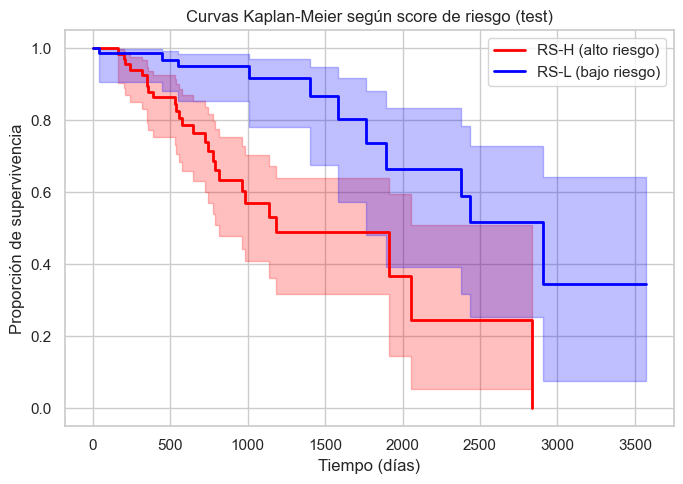

Log-rank P-value (test): 0.00002


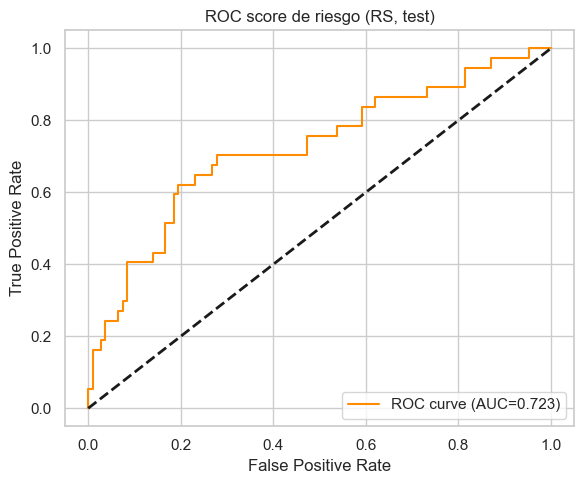

AUC del score de riesgo (test): 0.723


In [215]:
# ----------------------------
# Validación y visualización SOLO en test
# ----------------------------
# Separar por grupos de riesgo usando la mediana del score en test
try:
    median_risk = np.median(test_df['risk_score'])
    test_df['risk_group'] = (test_df['risk_score'] >= median_risk).astype(int)
    n_high = test_df['risk_group'].sum()
    n_low  = len(test_df) - n_high
    print(f'RS-H (riesgo alto): {n_high}, RS-L (riesgo bajo): {n_low}')
except Exception as e:
    print("Error al asignar grupos de riesgo:", e)

# Curvas Kaplan-Meier por grupo (test SOLO)
try:
    from lifelines import KaplanMeierFitter
    kmf_high = KaplanMeierFitter()
    kmf_low  = KaplanMeierFitter()

    fig, ax = plt.subplots(figsize=(7,5))
    mask_high = test_df['risk_group'] == 1
    mask_low  = test_df['risk_group'] == 0

    kmf_high.fit(
        durations=test_df.loc[mask_high, 'overall_survival'],
        event_observed=test_df.loc[mask_high, 'status'],
        label='RS-H (alto riesgo)'
    )
    kmf_low.fit(
        durations=test_df.loc[mask_low, 'overall_survival'],
        event_observed=test_df.loc[mask_low, 'status'],
        label='RS-L (bajo riesgo)'
    )
    kmf_high.plot(ax=ax, linewidth=2, color='red')
    kmf_low.plot(ax=ax, linewidth=2, color='blue')
    plt.title('Curvas Kaplan-Meier según score de riesgo (test)')
    plt.xlabel('Tiempo (días)')
    plt.ylabel('Proporción de supervivencia')
    plt.legend()
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Error en generación de curvas KM (test):", e)

# Prueba log-rank SOLO en test
try:
    from lifelines.statistics import logrank_test
    result = logrank_test(
        test_df.loc[mask_high, 'overall_survival'], test_df.loc[mask_low, 'overall_survival'],
        test_df.loc[mask_high, 'status'], test_df.loc[mask_low, 'status']
    )
    print(f"Log-rank P-value (test): {result.p_value:.5f}")
except Exception as e:
    print("Error en log-rank (test):", e)

# Curva ROC y AUC SOLO en test
try:
    from sklearn.metrics import roc_curve, roc_auc_score
    fpr, tpr, thresholds = roc_curve(test_df['status'], test_df['risk_score'])
    auc_value = roc_auc_score(test_df['status'], test_df['risk_score'])
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f'ROC curve (AUC={auc_value:.3f})', color='darkorange')
    plt.plot([0,1], [0,1], 'k--', lw=2)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC score de riesgo (RS, test)')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()
    print(f"AUC del score de riesgo (test): {auc_value:.3f}")
except Exception as e:
    print("Error en curva ROC/AUC (test):", e)

In [216]:
from lifelines.statistics import logrank_test

# Definir supervivencia binaria a 3 años (1095 días) en test
test_df['survival_3yr'] = (test_df['overall_survival'] >= 1095).astype(int)

# 1. Prueba log-rank entre grupos de riesgo en test
mask_high = test_df['risk_group'] == 1
mask_low  = test_df['risk_group'] == 0

result = logrank_test(
    test_df.loc[mask_high, 'overall_survival'],
    test_df.loc[mask_low, 'overall_survival'],
    test_df.loc[mask_high, 'status'],
    test_df.loc[mask_low, 'status']
)
print(f"Log-rank P-value (test, grupos RS): {result.p_value:.5f}")

# 2. AUC ROC para predicción de supervivencia a 3 años usando risk score (test)
auc_rs = roc_auc_score(test_df['survival_3yr'], -test_df['risk_score'])
# Nota: Negamos el score porque un score alto implica peor pronóstico
print(f"AUC ROC modelo Risk Score para supervivencia a 3 años (test): {auc_rs:.4f}")


Log-rank P-value (test, grupos RS): 0.00002
AUC ROC modelo Risk Score para supervivencia a 3 años (test): 0.6327


In [217]:
data_cox['survival_3yr'] = (data_cox['overall_survival'] >= 1095).astype(int)

In [218]:
data_cox.head()

attrib_name,CD4,ITGAM,CD7,CCL19,VCAM1,SPN,CD6,HLA-B,IRF7,SOCS3,HAVCR2,PRF1,GFAP,ISG20,RASSF5,PSMB9,LTBR,overall_survival,status,survival_3yr
TCGA.CS.4938,10.1129,8.7319,3.0962,1.9771,11.8776,6.5885,2.9473,12.5979,7.3408,5.0394,9.6075,3.2313,20.6716,2.4893,7.1831,7.9622,6.8678,3574.0,False,1
TCGA.CS.4941,10.8098,9.1757,4.9390,6.0033,10.3658,7.4562,5.7769,15.3449,9.7783,9.3375,10.4942,6.3161,19.1855,7.7639,8.2197,9.6491,8.2977,234.0,True,0
TCGA.CS.4942,11.6573,9.4815,4.1663,3.6741,11.6062,7.8802,3.3214,14.9115,9.1190,6.0902,10.9100,3.8226,19.4382,4.3242,8.2550,9.5610,8.2203,1335.0,True,1
TCGA.CS.4943,10.2035,8.5306,4.1130,5.3727,10.6845,5.9152,2.9110,12.2225,6.8056,5.1121,9.2059,3.2934,17.5538,3.5153,7.5408,6.9458,7.1450,1106.0,True,1
TCGA.CS.4944,9.5651,8.0758,3.4036,4.2598,8.0973,5.5972,4.0992,13.0791,7.6813,7.1052,8.8828,4.6267,21.2846,6.0457,6.7197,9.0181,7.2412,1828.0,False,1


In [219]:
categorical_cols = ['histological_type', 'gender', 'radiation_therapy']
numeric_cols = ['Tumor_purity', 'years_to_birth']  # Añadida years_to_birth

# Verificar existencia
for col in categorical_cols + numeric_cols:
    if col not in clin_sub.columns:
        raise ValueError(f"Columna '{col}' no encontrada en clin_sub")

# 1. Eliminar filas con cualquier valor faltante en las columnas de interés
relevant_cols = categorical_cols + numeric_cols
clin_sub_clean = clin_sub.dropna(subset=relevant_cols).copy()

print(f"✅ Filas con datos completos en {relevant_cols}: {clin_sub_clean.shape[0]}")

# 2. (Opcional) Convertir years_to_birth a edad positiva si es negativa
# En TCGA, years_to_birth suele ser negativo (ej. -45), por lo que se toma el valor absoluto
if clin_sub_clean['years_to_birth'].iloc[0] < 0:
    clin_sub_clean['years_to_birth'] = clin_sub_clean['years_to_birth'].abs()
    print("🔄 'years_to_birth' convertido a edad positiva (absoluto)")

# 3. Asegurar que las categóricas sean tipo 'object'
for col in categorical_cols:
    if pd.api.types.is_categorical_dtype(clin_sub_clean[col]):
        clin_sub_clean[col] = clin_sub_clean[col].astype('object')

# 4. One-hot encoding para variables categóricas
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_array = encoder.fit_transform(clin_sub_clean[categorical_cols])

encoded_feature_names = encoder.get_feature_names_out(categorical_cols)
encoded_df = pd.DataFrame(
    encoded_array,
    columns=encoded_feature_names,
    index=clin_sub_clean.index
)

# 5. Preparar variables numéricas: estandarizar 'years_to_birth' y mantener 'Tumor_purity' como está
from sklearn.preprocessing import StandardScaler

numeric_df = clin_sub_clean[numeric_cols].copy()

# Solo estandarizamos 'years_to_birth'; 'Tumor_purity' se mantiene sin escalar (o escala si decides)
scaler = StandardScaler()
numeric_df['years_to_birth'] = scaler.fit_transform(numeric_df[['years_to_birth']])

# Si también deseas estandarizar 'Tumor_purity', descomenta la siguiente línea:
# numeric_df['Tumor_purity'] = scaler.fit_transform(numeric_df[['Tumor_purity']])

# 6. Alinear y combinar con data_cox
data_cox_filtered = data_cox.loc[clin_sub_clean.index]
data_cox_final = pd.concat([data_cox_filtered, encoded_df, numeric_df], axis=1)

# 7. Guardar
output_path = '../data/data_cox_with_survival3yr_ht.csv'
data_cox_final.to_csv(output_path, index=True)

print(f"✅ Archivo guardado en: {output_path}")
print(f"   Forma final: {data_cox_final.shape}")
print(f"   Edad (years_to_birth) estandarizada: media = {numeric_df['years_to_birth'].mean():.2f}, std = {numeric_df['years_to_birth'].std():.2f}")

✅ Filas con datos completos en ['histological_type', 'gender', 'radiation_therapy', 'Tumor_purity', 'years_to_birth']: 464
✅ Archivo guardado en: ../data/data_cox_with_survival3yr_ht.csv
   Forma final: (464, 29)
   Edad (years_to_birth) estandarizada: media = 0.00, std = 1.00


C:\Users\Antonio\AppData\Local\Temp\ipykernel_12252\3835769478.py:23: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(clin_sub_clean[col]):
C:\Users\Antonio\AppData\Local\Temp\ipykernel_12252\3835769478.py:23: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(clin_sub_clean[col]):
C:\Users\Antonio\AppData\Local\Temp\ipykernel_12252\3835769478.py:23: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(clin_sub_clean[col]):


In [220]:
data_cox.head()

attrib_name,CD4,ITGAM,CD7,CCL19,VCAM1,SPN,CD6,HLA-B,IRF7,SOCS3,HAVCR2,PRF1,GFAP,ISG20,RASSF5,PSMB9,LTBR,overall_survival,status,survival_3yr
TCGA.CS.4938,10.1129,8.7319,3.0962,1.9771,11.8776,6.5885,2.9473,12.5979,7.3408,5.0394,9.6075,3.2313,20.6716,2.4893,7.1831,7.9622,6.8678,3574.0,False,1
TCGA.CS.4941,10.8098,9.1757,4.9390,6.0033,10.3658,7.4562,5.7769,15.3449,9.7783,9.3375,10.4942,6.3161,19.1855,7.7639,8.2197,9.6491,8.2977,234.0,True,0
TCGA.CS.4942,11.6573,9.4815,4.1663,3.6741,11.6062,7.8802,3.3214,14.9115,9.1190,6.0902,10.9100,3.8226,19.4382,4.3242,8.2550,9.5610,8.2203,1335.0,True,1
TCGA.CS.4943,10.2035,8.5306,4.1130,5.3727,10.6845,5.9152,2.9110,12.2225,6.8056,5.1121,9.2059,3.2934,17.5538,3.5153,7.5408,6.9458,7.1450,1106.0,True,1
TCGA.CS.4944,9.5651,8.0758,3.4036,4.2598,8.0973,5.5972,4.0992,13.0791,7.6813,7.1052,8.8828,4.6267,21.2846,6.0457,6.7197,9.0181,7.2412,1828.0,False,1


In [221]:
data_cox.info()

<class 'pandas.core.frame.DataFrame'>
Index: 481 entries, TCGA.CS.4938 to TCGA.WY.A85E
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CD4               481 non-null    float64
 1   ITGAM             481 non-null    float64
 2   CD7               481 non-null    float64
 3   CCL19             481 non-null    float64
 4   VCAM1             481 non-null    float64
 5   SPN               481 non-null    float64
 6   CD6               481 non-null    float64
 7   HLA-B             481 non-null    float64
 8   IRF7              481 non-null    float64
 9   SOCS3             481 non-null    float64
 10  HAVCR2            481 non-null    float64
 11  PRF1              481 non-null    float64
 12  GFAP              481 non-null    float64
 13  ISG20             481 non-null    float64
 14  RASSF5            481 non-null    float64
 15  PSMB9             481 non-null    float64
 16  LTBR              481 non-nul

In [222]:
# Elimina la columna original si existe
if 'histological_type' in data_cox.columns:
    data_cox = data_cox.drop('histological_type', axis=1)

# Elimina todas las columnas codificadas de tipos histológicos si existen
hist_cols = [col for col in data_cox.columns if col.startswith('histological_type')]
data_cox = data_cox.drop(hist_cols, axis=1)

# Guarda el DataFrame ya sin NADA de tipos histológicos
data_cox.to_csv('../data/data_cox_with_survival3yr.csv', index=True)

print("Archivo CSV guardado en '../data/data_cox_with_survival3yr.csv' sin los tipos histológicos")


Archivo CSV guardado en '../data/data_cox_with_survival3yr.csv' sin los tipos histológicos
